In [37]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os, pickle
from scipy.optimize import curve_fit
from tqdm import tqdm

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))
sys.path.append(functions_path)

In [38]:
base       = '/home/marian/CIGAR_ANALYSIS/CIGAR/data'
output_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/outputs'
os.makedirs(output_dir, exist_ok=True)

pretrigger = 125
font_size  = 18

plt.rcParams['font.family']       = 'serif'
plt.rcParams['mathtext.fontset']  = 'cm'
plt.rcParams['font.size']         = font_size

GS_COLORS = ['#000000','#1a1a1a','#333333','#4d4d4d','#666666',
             '#808080','#999999','#b3b3b3','#cccccc','#e6e6e6']
colors = GS_COLORS

In [39]:
# ── Model functions (identical to TimeConstants_Suzuki_v3) ─────────────────

def _rise_decay_normalised(t, t0, rise, decay):
    s = np.zeros_like(t, dtype=float)
    mask = t >= t0
    s[mask] = (1.0 - np.exp(-(t[mask]-t0)/rise)) * np.exp(-(t[mask]-t0)/decay)
    area = np.trapz(s, x=t)
    return s / (area if area != 0 else 1.0)

def _I(p, q, u):
    if np.abs(p - q) < 1e-30:
        return u * np.exp(-p * u)
    return (np.exp(-p * u) - np.exp(-q * u)) / (q - p)

def _conv_two_rise_decay(u, rise1, decay1, rise2, decay2):
    a = 1.0/decay1;  b = 1.0/rise1 + 1.0/decay1
    c = 1.0/decay2;  d = 1.0/rise2 + 1.0/decay2
    return _I(a,c,u) - _I(a,d,u) - _I(b,c,u) + _I(b,d,u)

def recombination_model(t, t0, tau_rec, Tr):
    u    = t - t0
    mask = u > 0
    out  = np.zeros_like(t, dtype=float)
    out[mask] = (1.0 - np.exp(-u[mask]/tau_rec)) * (1.0 + u[mask]/Tr)**-2
    return out

def CIGARResponse_analytical(t, t0,
                             A_singlet, rise_singlet, tau_singlet,
                             A_triplet, rise_triplet, tau_triplet,
                             A_rec,     tau_rec,      Tr,
                             baseline=0.0):
    sipm_rise  = 1e-9
    sipm_decay = 64e-9
    u    = t - t0
    mask = u > 0

    h_s       = np.zeros_like(t, dtype=float)
    h_s[mask] = _conv_two_rise_decay(u[mask], rise_singlet, tau_singlet, sipm_rise, sipm_decay)
    area = np.trapz(h_s, x=t)
    if area > 0: h_s *= A_singlet / area

    h_t       = np.zeros_like(t, dtype=float)
    h_t[mask] = _conv_two_rise_decay(u[mask], rise_triplet, tau_triplet, sipm_rise, sipm_decay)
    area = np.trapz(h_t, x=t)
    if area > 0: h_t *= A_triplet / area

    h_r  = recombination_model(t, t0, tau_rec, Tr)
    area = np.trapz(h_r, x=t)
    if area > 0: h_r *= A_rec / area

    return baseline + h_s + h_t + h_r

In [40]:
# ── Empirical Tr(P) from RecombinationTr notebook ───────────────────────────
_TR_A     = {'CH1': 79.8,  'CH2': 92.4,  'CH3': 90.5,  'CH4': 83.6}
_TR_ALPHA = {'CH1': -1.377,'CH2': -1.408,'CH3': -1.377,'CH4': -1.360}

PARAM_NAMES_S1 = ['t0', 'A_singlet', 'A_triplet', 'rise_triplet', 'A_rec', 'Tr']

def _check_bounds_s1(popt, lo, hi, tol=0.02):
    """Return a list of '⚠ name [hi/lo]' strings for params within tol of a bound."""
    warnings = []
    for name, p, l, h in zip(PARAM_NAMES_S1, popt, lo, hi):
        span = h - l if not np.isinf(h) else None
        if span is not None and span > 0:
            if (p - l) / span < tol:
                warnings.append(f'!! {name} → lo')
            elif (h - p) / span < tol:
                warnings.append(f'!! {name} → hi')
    return warnings


def fit_amplitudes_stage1(t_fit, wf_fit, t0_fixed, dt_samp, baseline_est, Tr_guess):
    """Stage-1: tau_singlet=39 ns, tau_triplet=2.16 µs FIXED.
    6 free: t0, A_singlet, A_triplet, rise_triplet, A_rec, Tr.

    Initial guesses are derived from area integrals of the waveform in three
    characteristic time windows rather than fixed A_tot fractions.

    Returns
    -------
    popt  : [t0, A_singlet, A_triplet, rise_triplet, A_rec, Tr]
    pcov  : 6×6 covariance
    A_tot : waveform area (baseline-subtracted)
    bounds: (lo, hi) lists used
    """
    t0_window = 10 * dt_samp
    wf_bl = wf_fit - baseline_est
    A_tot = max(np.trapz(wf_bl, x=t_fit),
                wf_bl.max() * (t_fit[-1] - t_fit[0]) * 0.1)
    A_tot = max(A_tot, 1e-15)

    # ── Data-driven initial amplitude estimates ───────────────────────────
    # Window boundaries based on characteristic times:
    #   t_cut1 ~ 10×tau_singlet_eff (~600 ns): singlet+SiPM fully decayed
    #   t_cut2 ~ 2.5×tau_triplet (~5 µs): triplet mostly decayed
    t_cut1 = t0_fixed + 600e-9
    t_cut2 = t0_fixed + 5.0e-6

    m_early = t_fit < t_cut1
    m_late  = t_fit >= t_cut2
    _pos    = np.maximum(wf_bl, 0)
    A_early = np.trapz(_pos[m_early], x=t_fit[m_early]) if m_early.sum() > 1 else A_tot * 0.15
    A_late  = np.trapz(_pos[m_late],  x=t_fit[m_late])  if m_late.sum()  > 1 else A_tot * 0.15

    # A_early ≈ A_singlet + 0.24*A_triplet  (24% of triplet area lies in 0–600 ns)
    # A_late  ≈ 0.10*A_triplet + most of A_rec  (tail beyond 5 µs)
    # Use 30% of early window as singlet estimate; 130% of late window as rec estimate
    A_s_est = max(A_early * 0.30,  A_tot * 0.02)
    A_r_est = max(A_late  * 1.30,  A_tot * 0.02)
    A_t_est = max(A_tot - A_s_est - A_r_est, A_tot * 0.05)

    def _fn(t, t0, As, At, rt, Ar, Tr):
        return CIGARResponse_analytical(t, t0=t0,
            A_singlet=As, rise_singlet=1e-9, tau_singlet=39e-9,
            A_triplet=At, rise_triplet=rt,   tau_triplet=2.16e-6,
            A_rec=Ar,     tau_rec=2.16e-6,   Tr=Tr,
            baseline=baseline_est)

    p0 = [t0_fixed, A_s_est, A_t_est, 150e-9, A_r_est, Tr_guess]

    lo = [t0_fixed - t0_window,
          1e-15, 1e-15, 10e-9, 1e-15,
          Tr_guess * 0.01]
    hi = [t0_fixed + t0_window,
          A_tot * 4.0, A_tot * 4.0, 500e-9, A_tot * 4.0,
          max(Tr_guess * 20.0, 800e-6)]    # wide Tr upper — large at low pressure

    for i in range(6):
        hi_v = hi[i] if not np.isinf(hi[i]) else 1e20
        p0[i] = float(np.clip(p0[i],
                               lo[i] + abs(lo[i]) * 1e-6 + 1e-30,
                               hi_v  - abs(hi_v)  * 1e-6))

    popt, pcov = curve_fit(_fn, t_fit, wf_fit,
                           p0=p0, bounds=(lo, hi),
                           maxfev=60_000, ftol=1e-12, xtol=1e-12)
    return popt, pcov, A_tot, (lo, hi)

In [41]:
def plot_stage1_at_pressure(bars, run_name, amp_results, base, pretrigger,
                             colors, font_size=18, logscale=True):
    """2×2 channel figure showing Stage-1 fit decomposition at one pressure.
    Mirrors the per-pressure plots produced by fit_cigar_waveforms in v3.
    """
    npz          = np.load(f'{base}/mean_waveforms/mean_waveforms_{run_name}.npz', allow_pickle=True)
    channels_arr = npz['channels']
    time_arr     = npz['time']
    t0_line      = float(time_arr[pretrigger])

    fig, axs = plt.subplots(2, 2, figsize=(20, 14), dpi=150)
    fig.suptitle(
        fr'Stage-1 fits  ($\tau_s$ = 39 ns, $\tau_t$ = 2.16 µs fixed)  —  {bars} bar',
        fontsize=font_size + 2)

    for ch_idx, ch in enumerate(channels_arr[:4]):
        ax  = axs.flat[ch_idx]
        sk  = f'CH{ch_idx+1}'
        wf  = -npz[f'ch_{ch}'].copy()

        baseline_est = float(np.mean(wf[:pretrigger//3]))
        fit_mask     = time_arr >= time_arr[pretrigger]
        t_fit        = time_arr[fit_mask]
        wf_fit       = wf[fit_mask]

        ax.plot(t_fit * 1e6, wf_fit, '-', lw=1.5, color=colors[ch_idx],
                alpha=0.65, label='Data')

        ar = (amp_results.get(sk) or {}).get(bars)
        if ar is not None and ar.get('fit_ok', False):
            t0_  = ar['t0']
            As   = ar['A_singlet']
            At   = ar['A_triplet']
            rt   = ar['rise_triplet']
            Ar   = ar['A_rec']
            Tr   = ar['Tr']

            def _fn_plot(t, t0, As, At, rt, Ar, Tr):
                return CIGARResponse_analytical(t, t0=t0,
                    A_singlet=As, rise_singlet=1e-9, tau_singlet=39e-9,
                    A_triplet=At, rise_triplet=rt,   tau_triplet=2.16e-6,
                    A_rec=Ar,     tau_rec=2.16e-6,   Tr=Tr,
                    baseline=baseline_est)

            wf_model = _fn_plot(t_fit, t0_, As, At, rt, Ar, Tr)
            ax.plot(t_fit * 1e6, wf_model, 'r-', lw=2.5, zorder=5, label='Stage-1 fit')

            u    = t_fit - t0_
            mask = u > 0

            h_s       = np.zeros_like(t_fit)
            h_s[mask] = _conv_two_rise_decay(u[mask], 1e-9, 39e-9, 1e-9, 64e-9)
            a_ = np.trapz(h_s, x=t_fit)
            if a_ > 0: h_s *= As / a_

            h_t       = np.zeros_like(t_fit)
            h_t[mask] = _conv_two_rise_decay(u[mask], rt, 2.16e-6, 1e-9, 64e-9)
            a_ = np.trapz(h_t, x=t_fit)
            if a_ > 0: h_t *= At / a_

            h_r  = recombination_model(t_fit, t0_, 2.16e-6, Tr)
            a_   = np.trapz(h_r, x=t_fit)
            if a_ > 0: h_r *= Ar / a_

            bl = baseline_est
            ax.plot(t_fit*1e6, h_s+bl, '--', lw=2.5, alpha=0.80, color=colors[2], label='Singlet')
            ax.fill_between(t_fit*1e6, bl, h_s+bl, alpha=0.15, color=colors[2])
            ax.plot(t_fit*1e6, h_t+bl, '-.', lw=2.5, alpha=0.80, color=colors[5], label='Triplet')
            ax.fill_between(t_fit*1e6, bl, h_t+bl, alpha=0.15, color=colors[5])
            ax.plot(t_fit*1e6, h_r+bl, ':',  lw=2.5, alpha=0.80, color=colors[7], label='Recomb')
            ax.fill_between(t_fit*1e6, bl, h_r+bl, alpha=0.15, color=colors[7])

            A_sum = As + At + Ar
            clip_str = '  '.join(ar.get('clip_warnings', []))
            annot = (fr"$f_s$ = {As/A_sum:.3f}   $f_t$ = {At/A_sum:.3f}   $f_r$ = {Ar/A_sum:.3f}" + "\n"
                     fr"rise$_t$ = {rt*1e9:.0f} ns     $T_r$ = {Tr*1e6:.2f} µs")
            if clip_str:
                annot += f'\n{clip_str}'
            ax.annotate(annot,
                        xy=(0.97, 0.97), xycoords='axes fraction',
                        ha='right', va='top', fontsize=font_size * 0.65,
                        bbox=dict(boxstyle='round,pad=0.35', fc='white', alpha=0.88))

        ax.axvline(t0_line * 1e6, color='k', ls=':', alpha=0.35)
        ax.axhline(0, color='k', ls=':', alpha=0.25)
        ax.set_title(sk, fontsize=font_size)
        ax.set_xlabel('Time [µs]', fontsize=font_size * 0.85)
        ax.set_ylabel('Amplitude [mV]', fontsize=font_size * 0.85)
        ax.set_xlim(0, 16)
        ax.legend(loc='center right', fontsize=font_size * 0.60)
        if logscale:
            ax.set_yscale('log')
            _lo = max(np.nanmin(wf_fit[wf_fit > 0]) * 0.3, 1e-2) if np.any(wf_fit > 0) else 1e-2
            ax.set_ylim(_lo, wf_fit.max() * 3)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [42]:
runs = {
    8.5: 'Run171',
    7.5: 'Run173',
    6.5: 'Run175',
    5.5: 'Run177',
    4.5: 'Run179',
    3.5: 'Run181',
    2.5: 'Run183',
    1.5: 'Run185',
}


── 8.5 bar (Run171) ─────────────────────
  CH1: fs=0.062  ft=0.358  fr=0.580  rt=19 ns  Tr=9.0 µs  !! A_singlet → lo  !! rise_triplet → lo  !! Tr → lo
  CH2: fs=0.061  ft=0.359  fr=0.579  rt=18 ns  Tr=9.2 µs  !! A_singlet → lo  !! rise_triplet → lo  !! Tr → lo
  CH3: fs=0.055  ft=0.356  fr=0.590  rt=18 ns  Tr=9.7 µs  !! A_singlet → lo  !! rise_triplet → lo  !! Tr → lo
  CH4: fs=0.062  ft=0.355  fr=0.583  rt=20 ns  Tr=8.9 µs  !! A_singlet → lo  !! Tr → lo


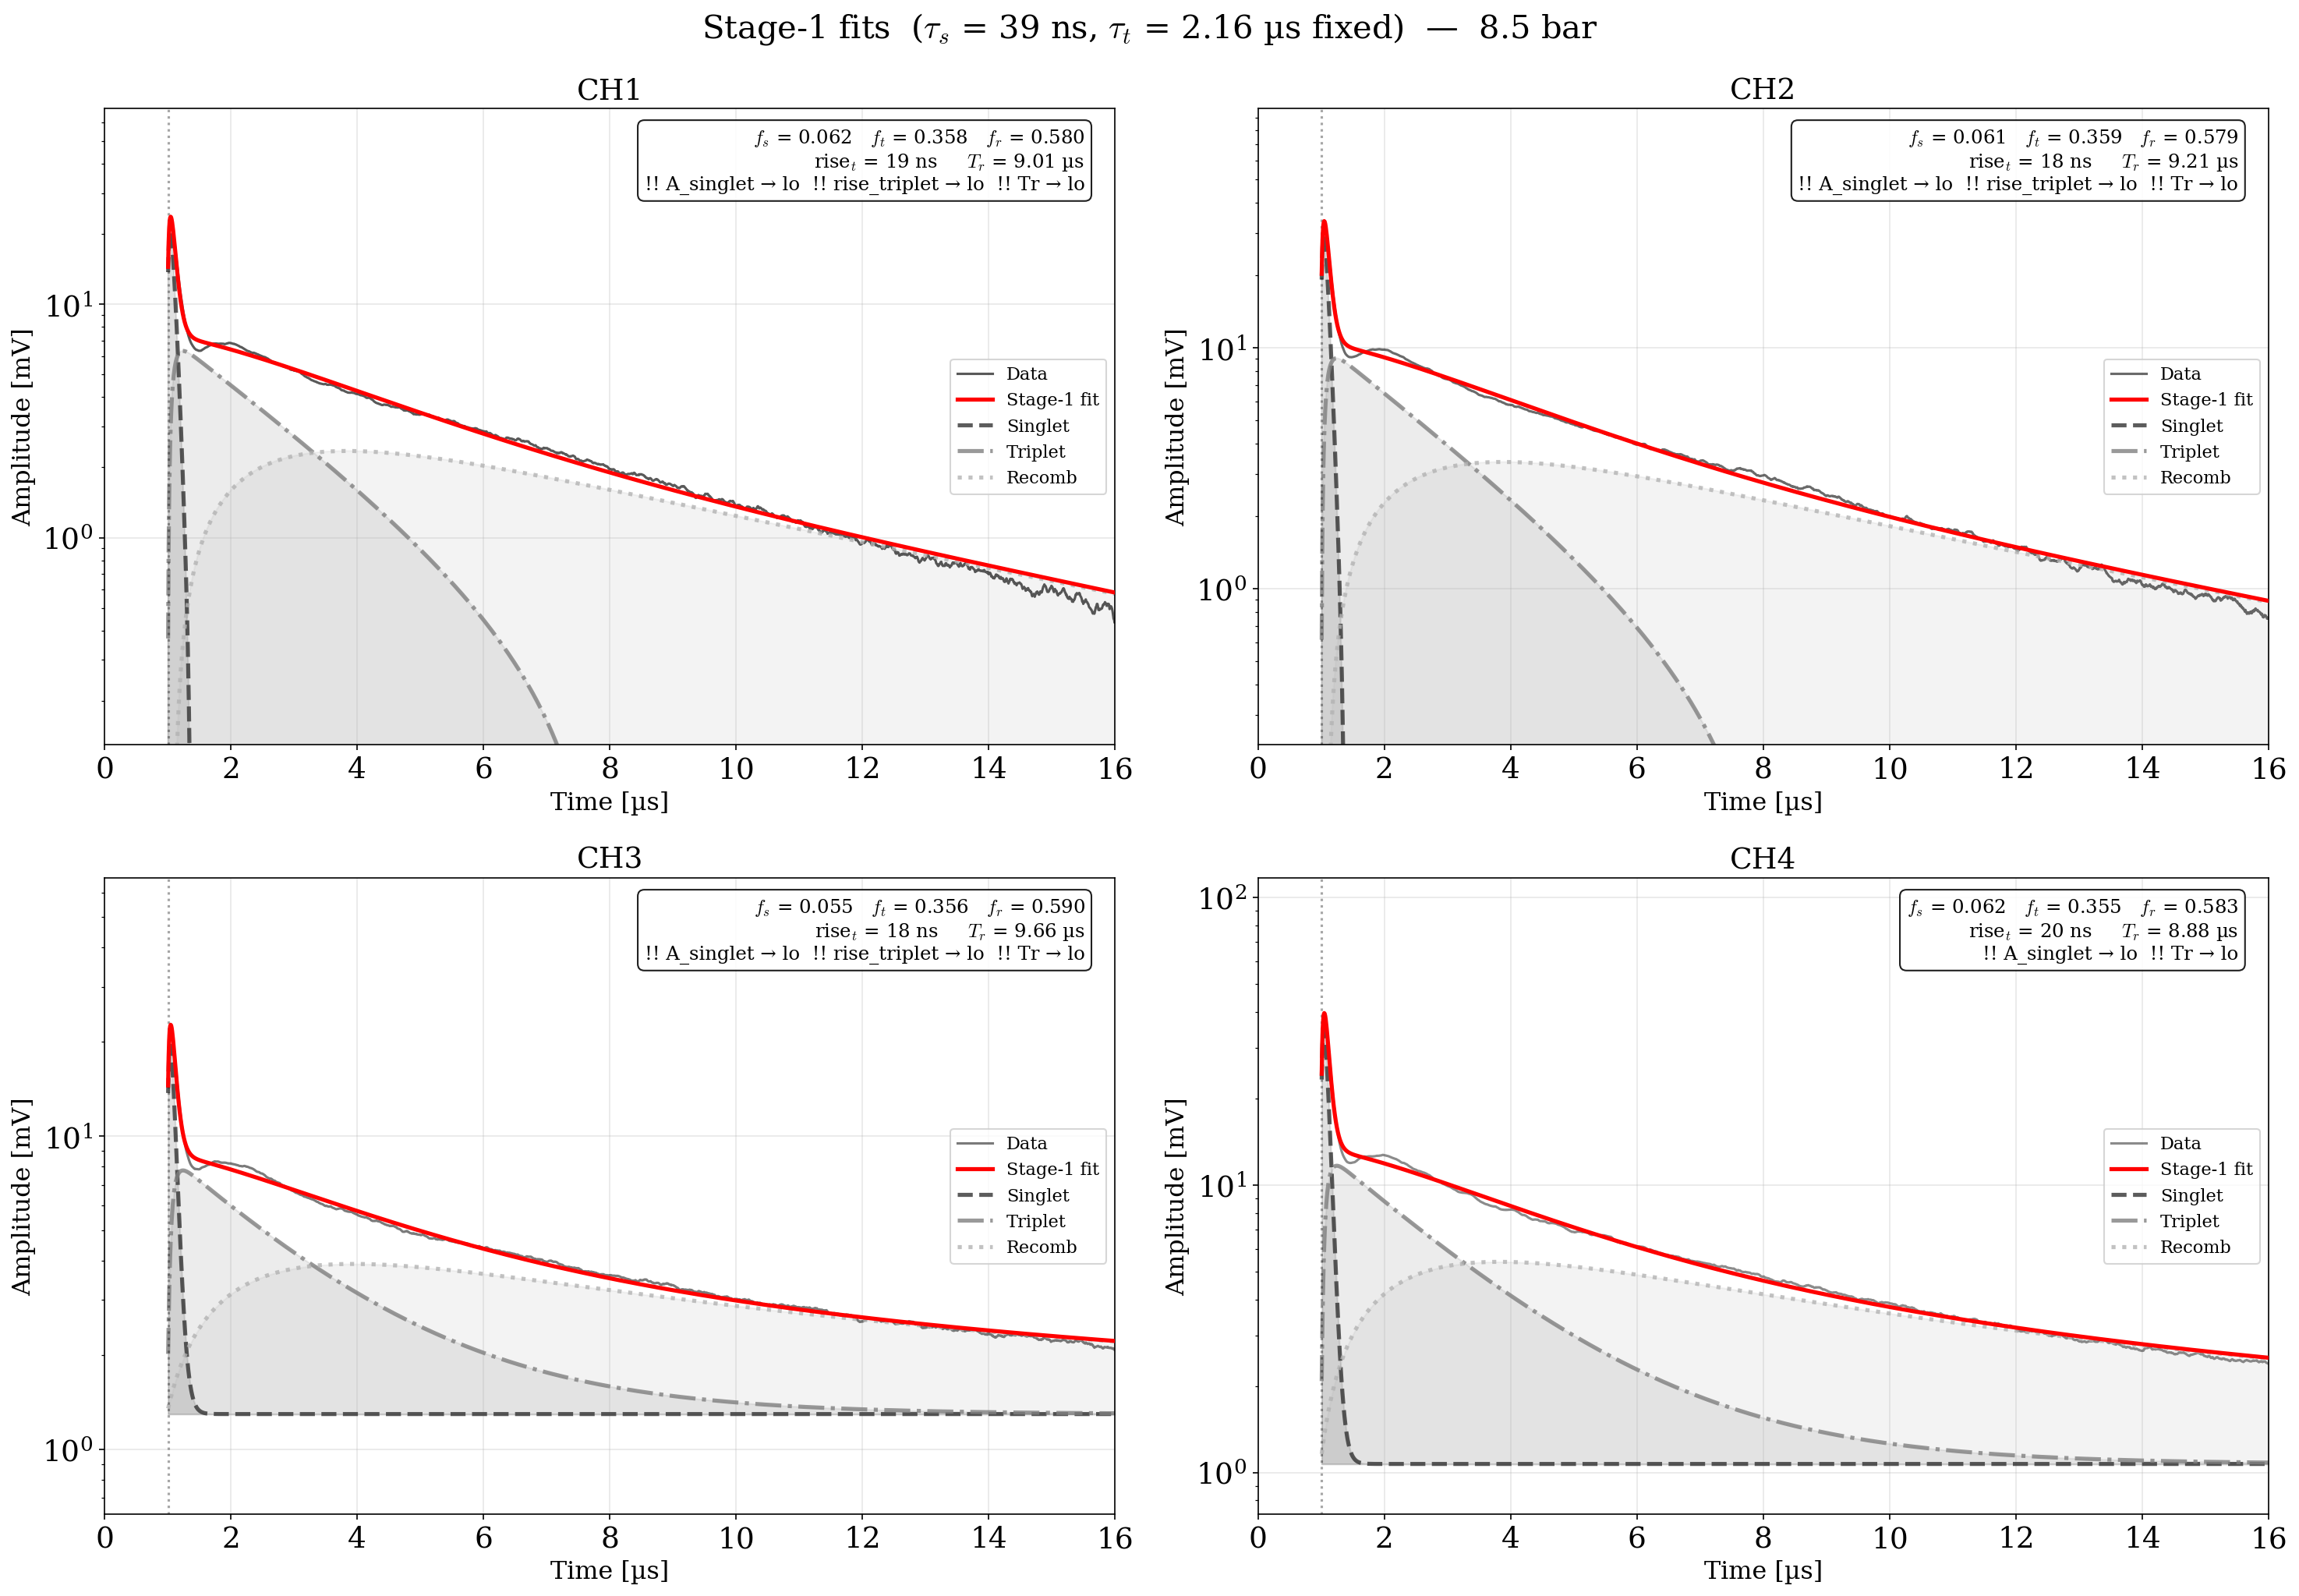


── 7.5 bar (Run173) ─────────────────────
  CH1: fs=0.074  ft=0.345  fr=0.581  rt=22 ns  Tr=10.1 µs  !! A_singlet → lo  !! Tr → lo
  CH2: fs=0.074  ft=0.341  fr=0.585  rt=24 ns  Tr=10.2 µs  !! A_singlet → lo  !! Tr → lo
  CH3: fs=0.066  ft=0.340  fr=0.594  rt=18 ns  Tr=10.7 µs  !! A_singlet → lo  !! rise_triplet → lo  !! Tr → lo
  CH4: fs=0.073  ft=0.343  fr=0.583  rt=18 ns  Tr=10.3 µs  !! A_singlet → lo  !! rise_triplet → lo  !! Tr → lo


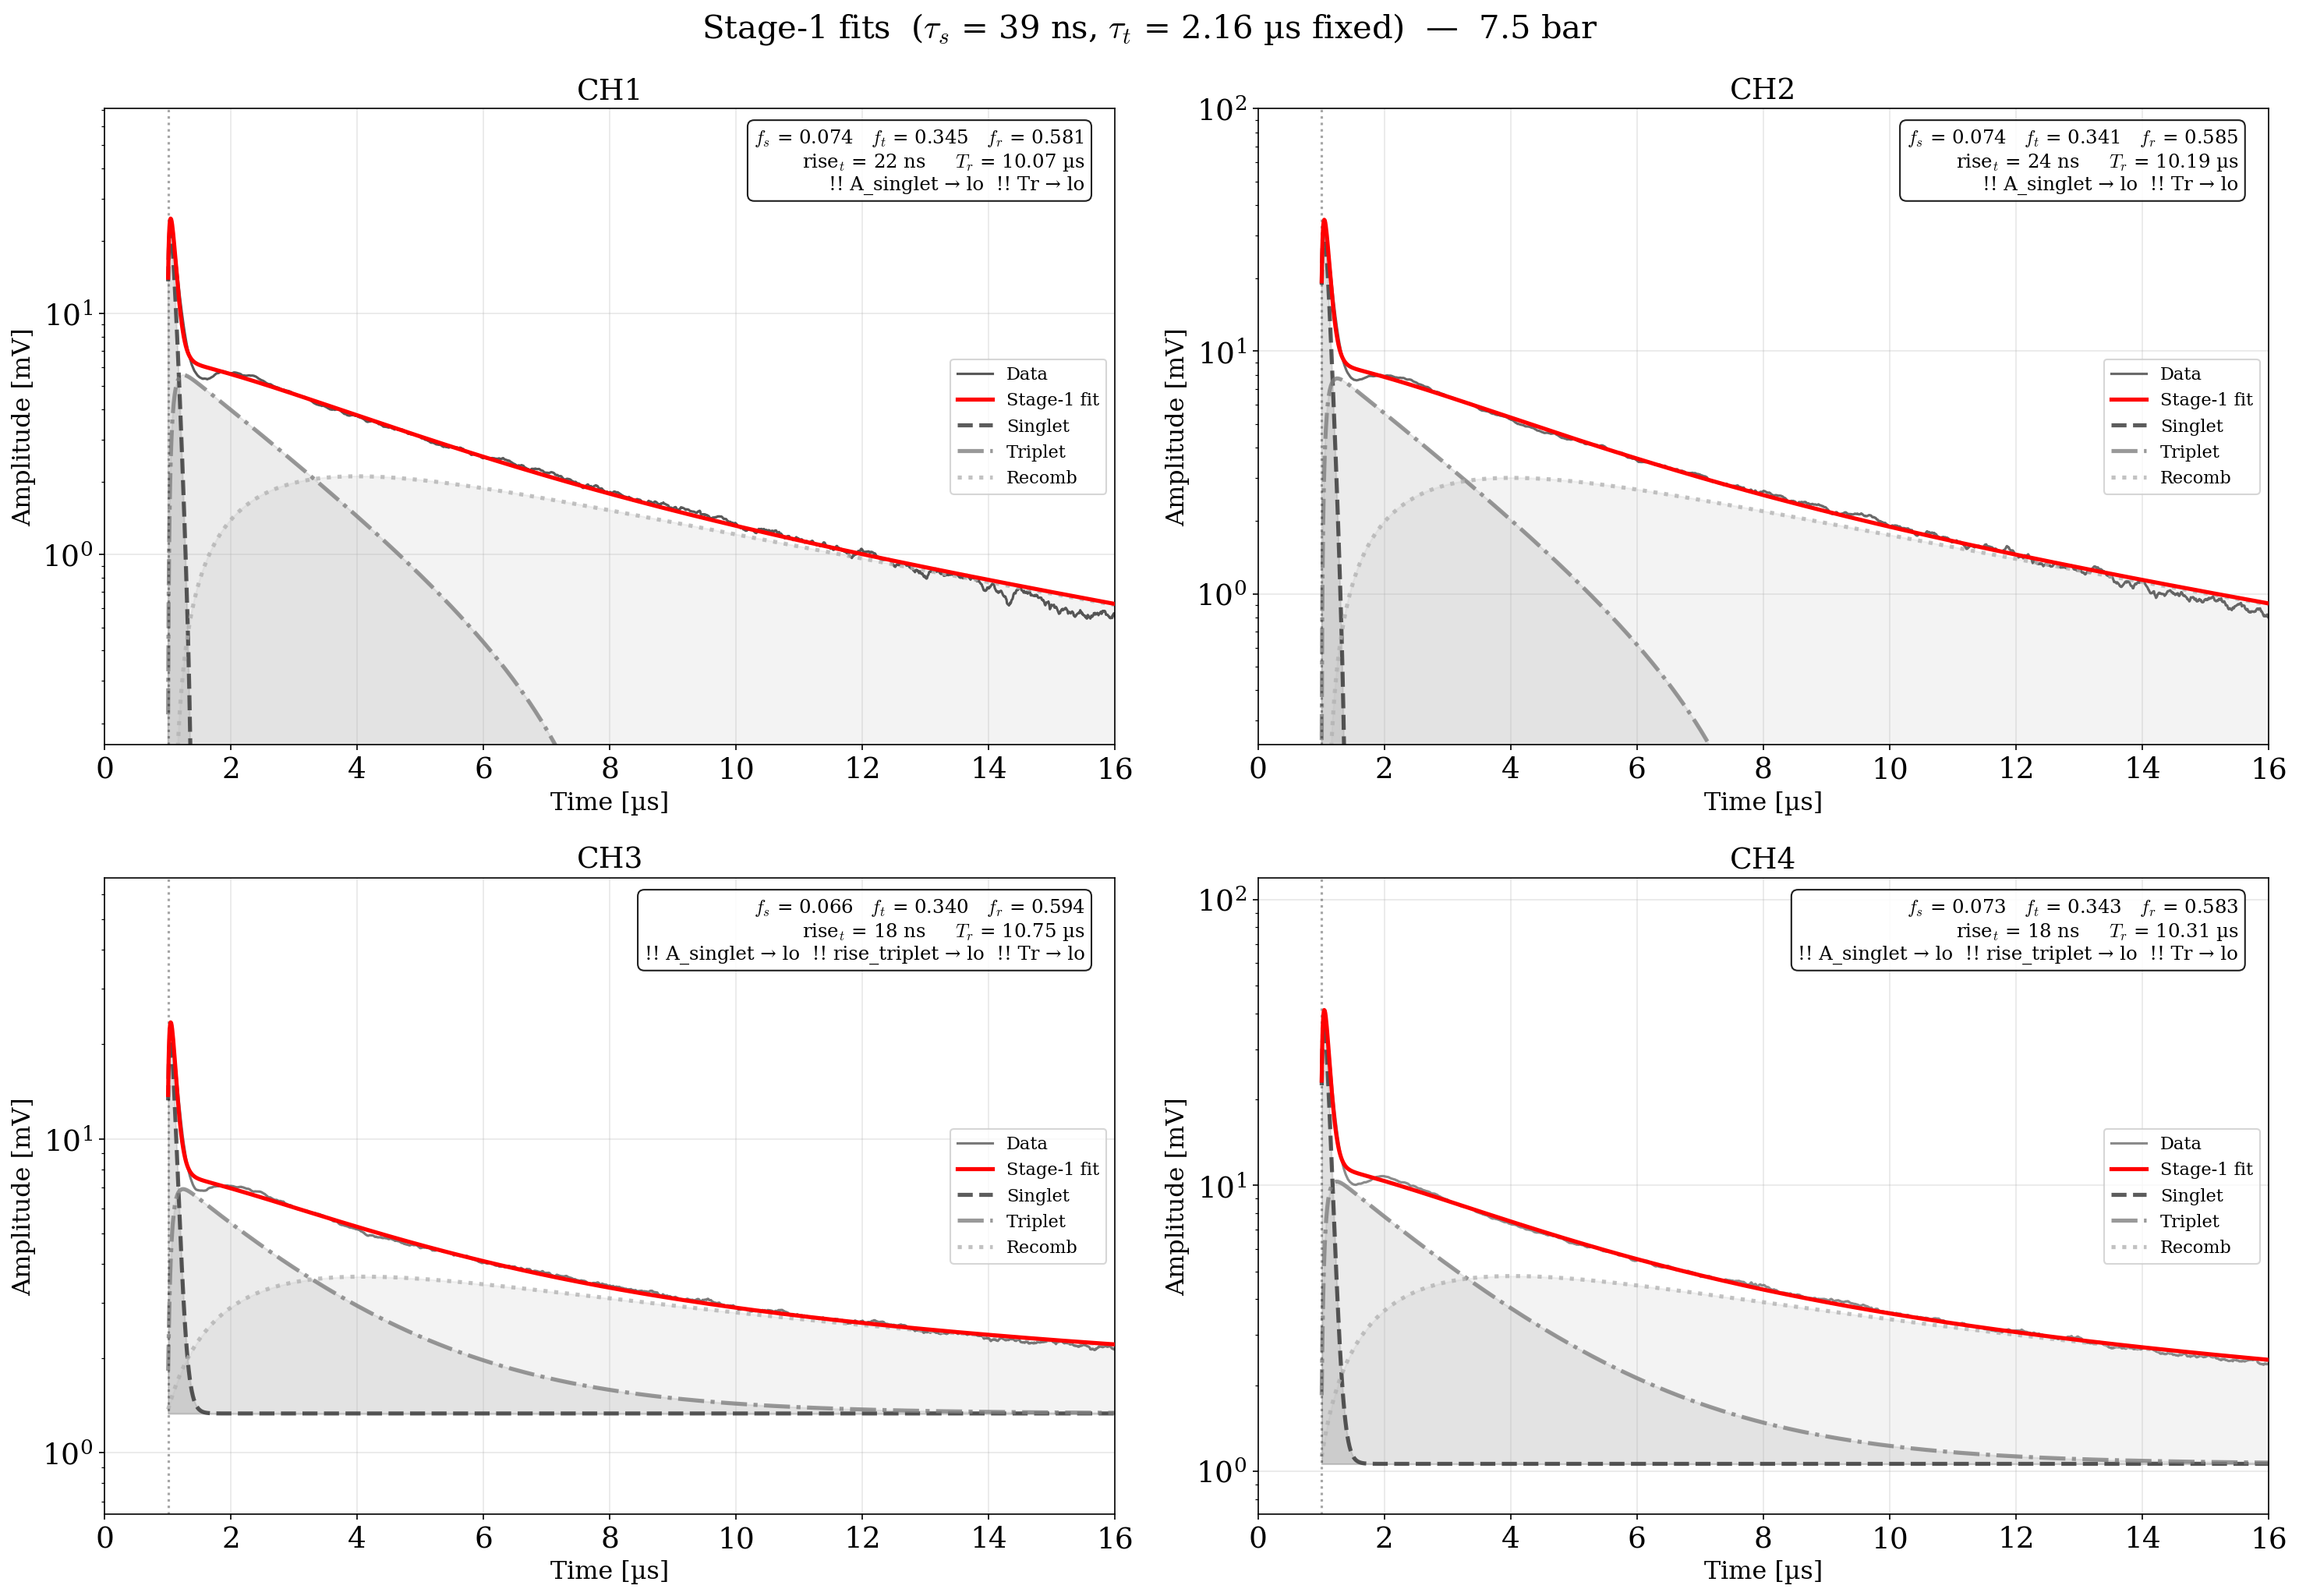


── 6.5 bar (Run175) ─────────────────────
  CH1: fs=0.092  ft=0.329  fr=0.579  rt=23 ns  Tr=12.3 µs  !! Tr → lo
  CH2: fs=0.091  ft=0.332  fr=0.577  rt=22 ns  Tr=12.7 µs  !! Tr → lo
  CH3: fs=0.084  ft=0.327  fr=0.589  rt=22 ns  Tr=13.0 µs  !! Tr → lo
  CH4: fs=0.092  ft=0.321  fr=0.587  rt=25 ns  Tr=12.2 µs  !! Tr → lo


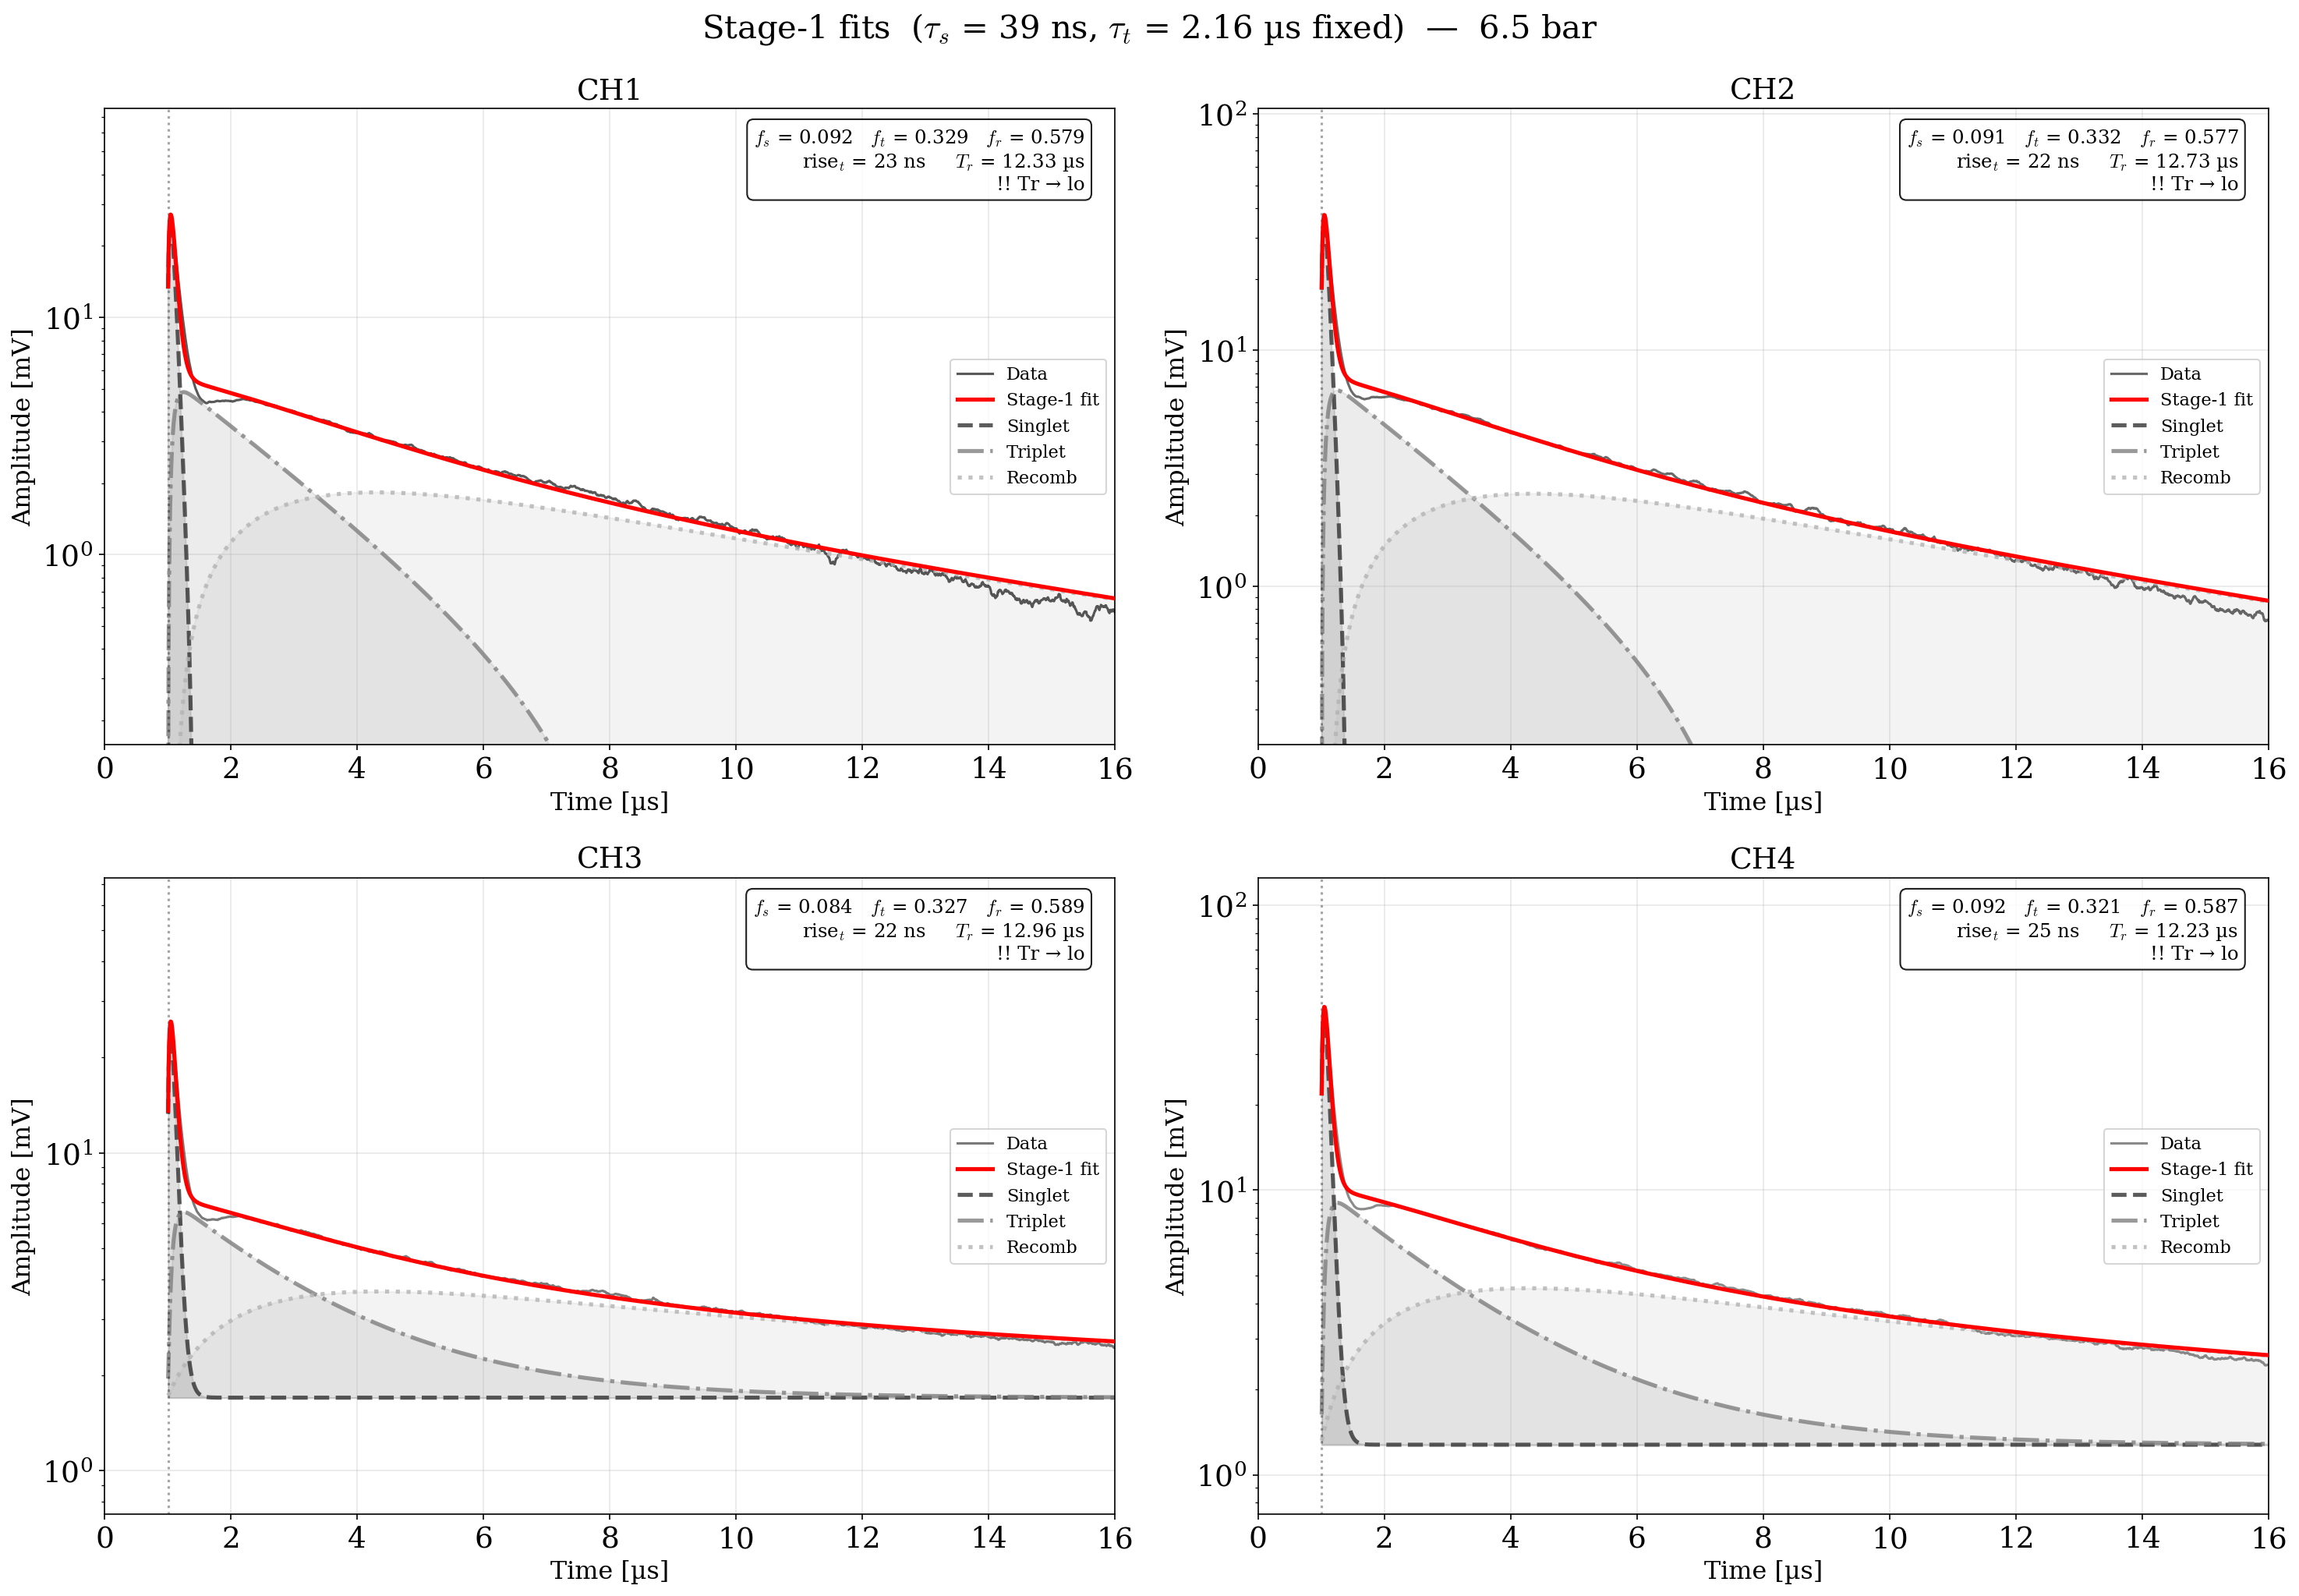


── 5.5 bar (Run177) ─────────────────────
  CH1: fs=0.110  ft=0.356  fr=0.534  rt=20 ns  Tr=28.4 µs
  CH2: fs=0.108  ft=0.353  fr=0.538  rt=20 ns  Tr=28.1 µs
  CH3: fs=0.102  ft=0.326  fr=0.572  rt=19 ns  Tr=18.6 µs  !! rise_triplet → lo
  CH4: fs=0.113  ft=0.326  fr=0.561  rt=24 ns  Tr=17.8 µs


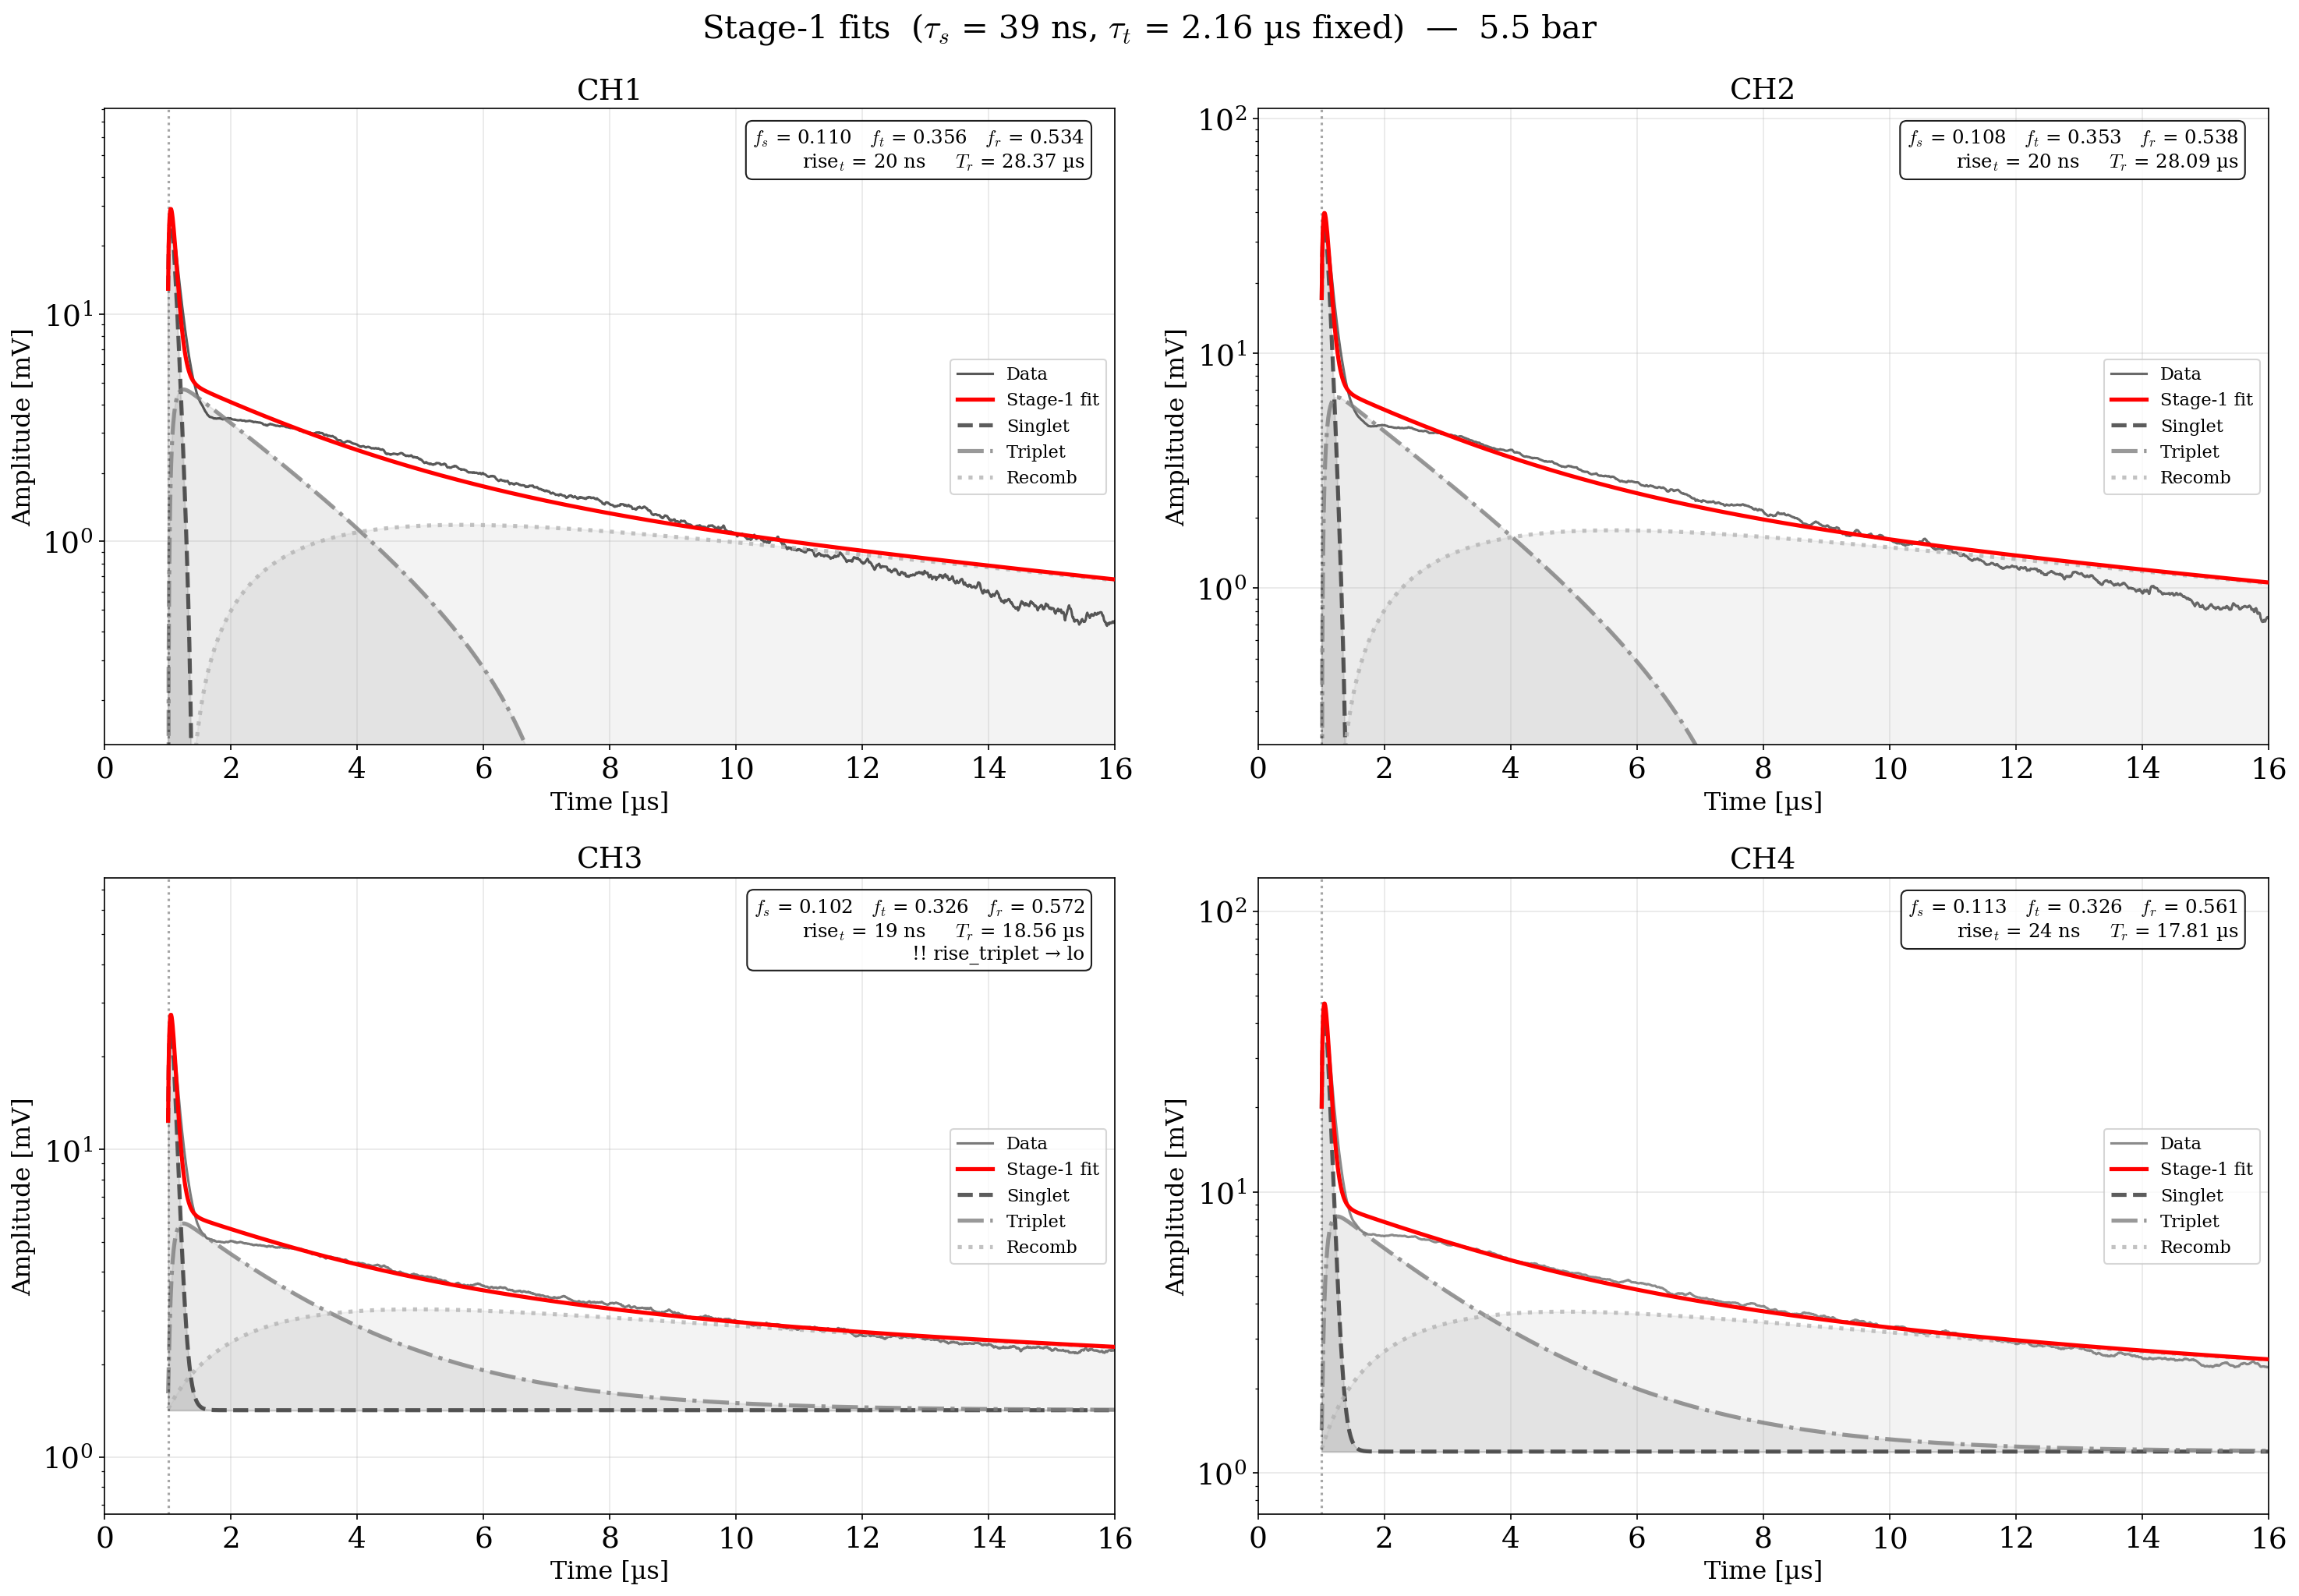


── 4.5 bar (Run179) ─────────────────────
  CH1: fs=0.136  ft=0.374  fr=0.490  rt=23 ns  Tr=44.9 µs
  CH2: fs=0.135  ft=0.369  fr=0.496  rt=23 ns  Tr=45.5 µs
  CH3: fs=0.129  ft=0.357  fr=0.514  rt=23 ns  Tr=40.2 µs
  CH4: fs=0.139  ft=0.364  fr=0.497  rt=22 ns  Tr=42.2 µs


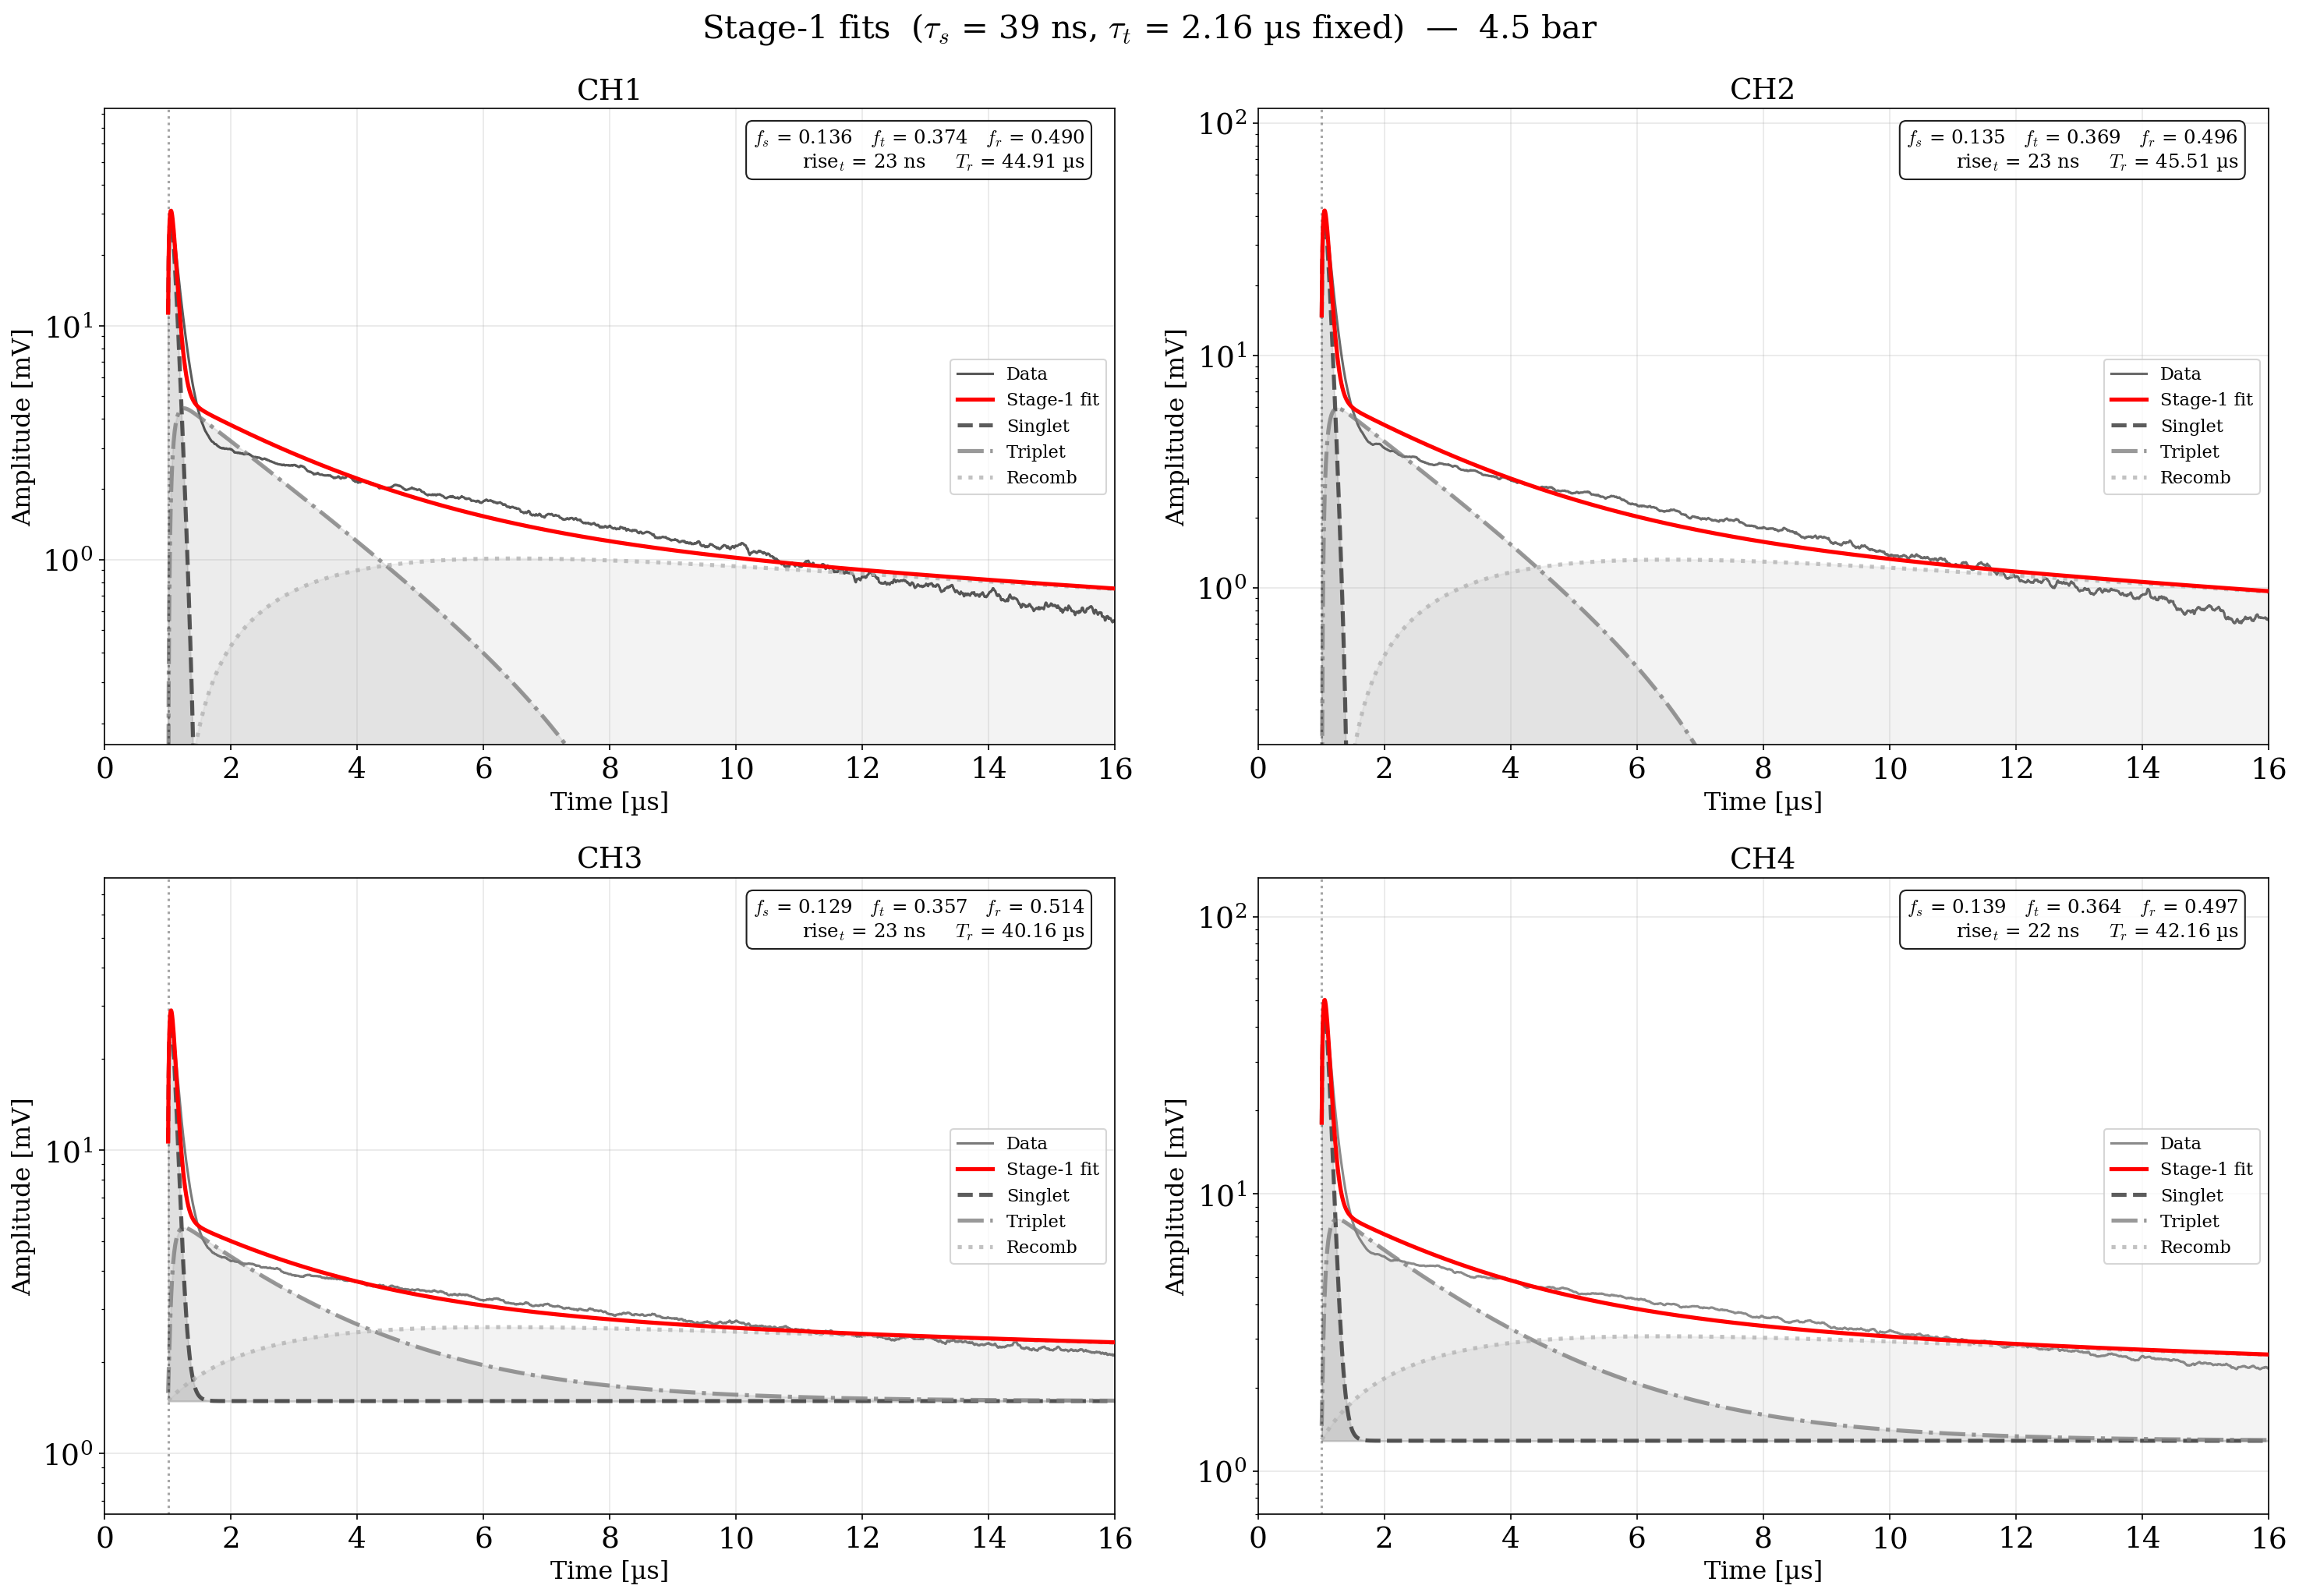


── 3.5 bar (Run181) ─────────────────────
  CH1: fs=0.163  ft=0.462  fr=0.375  rt=15 ns  Tr=458.5 µs  !! rise_triplet → lo
  CH2: fs=0.160  ft=0.456  fr=0.384  rt=14 ns  Tr=477.3 µs  !! rise_triplet → lo
  CH3: fs=0.153  ft=0.442  fr=0.405  rt=13 ns  Tr=449.1 µs  !! rise_triplet → lo
  CH4: fs=0.165  ft=0.447  fr=0.388  rt=15 ns  Tr=461.2 µs  !! rise_triplet → lo


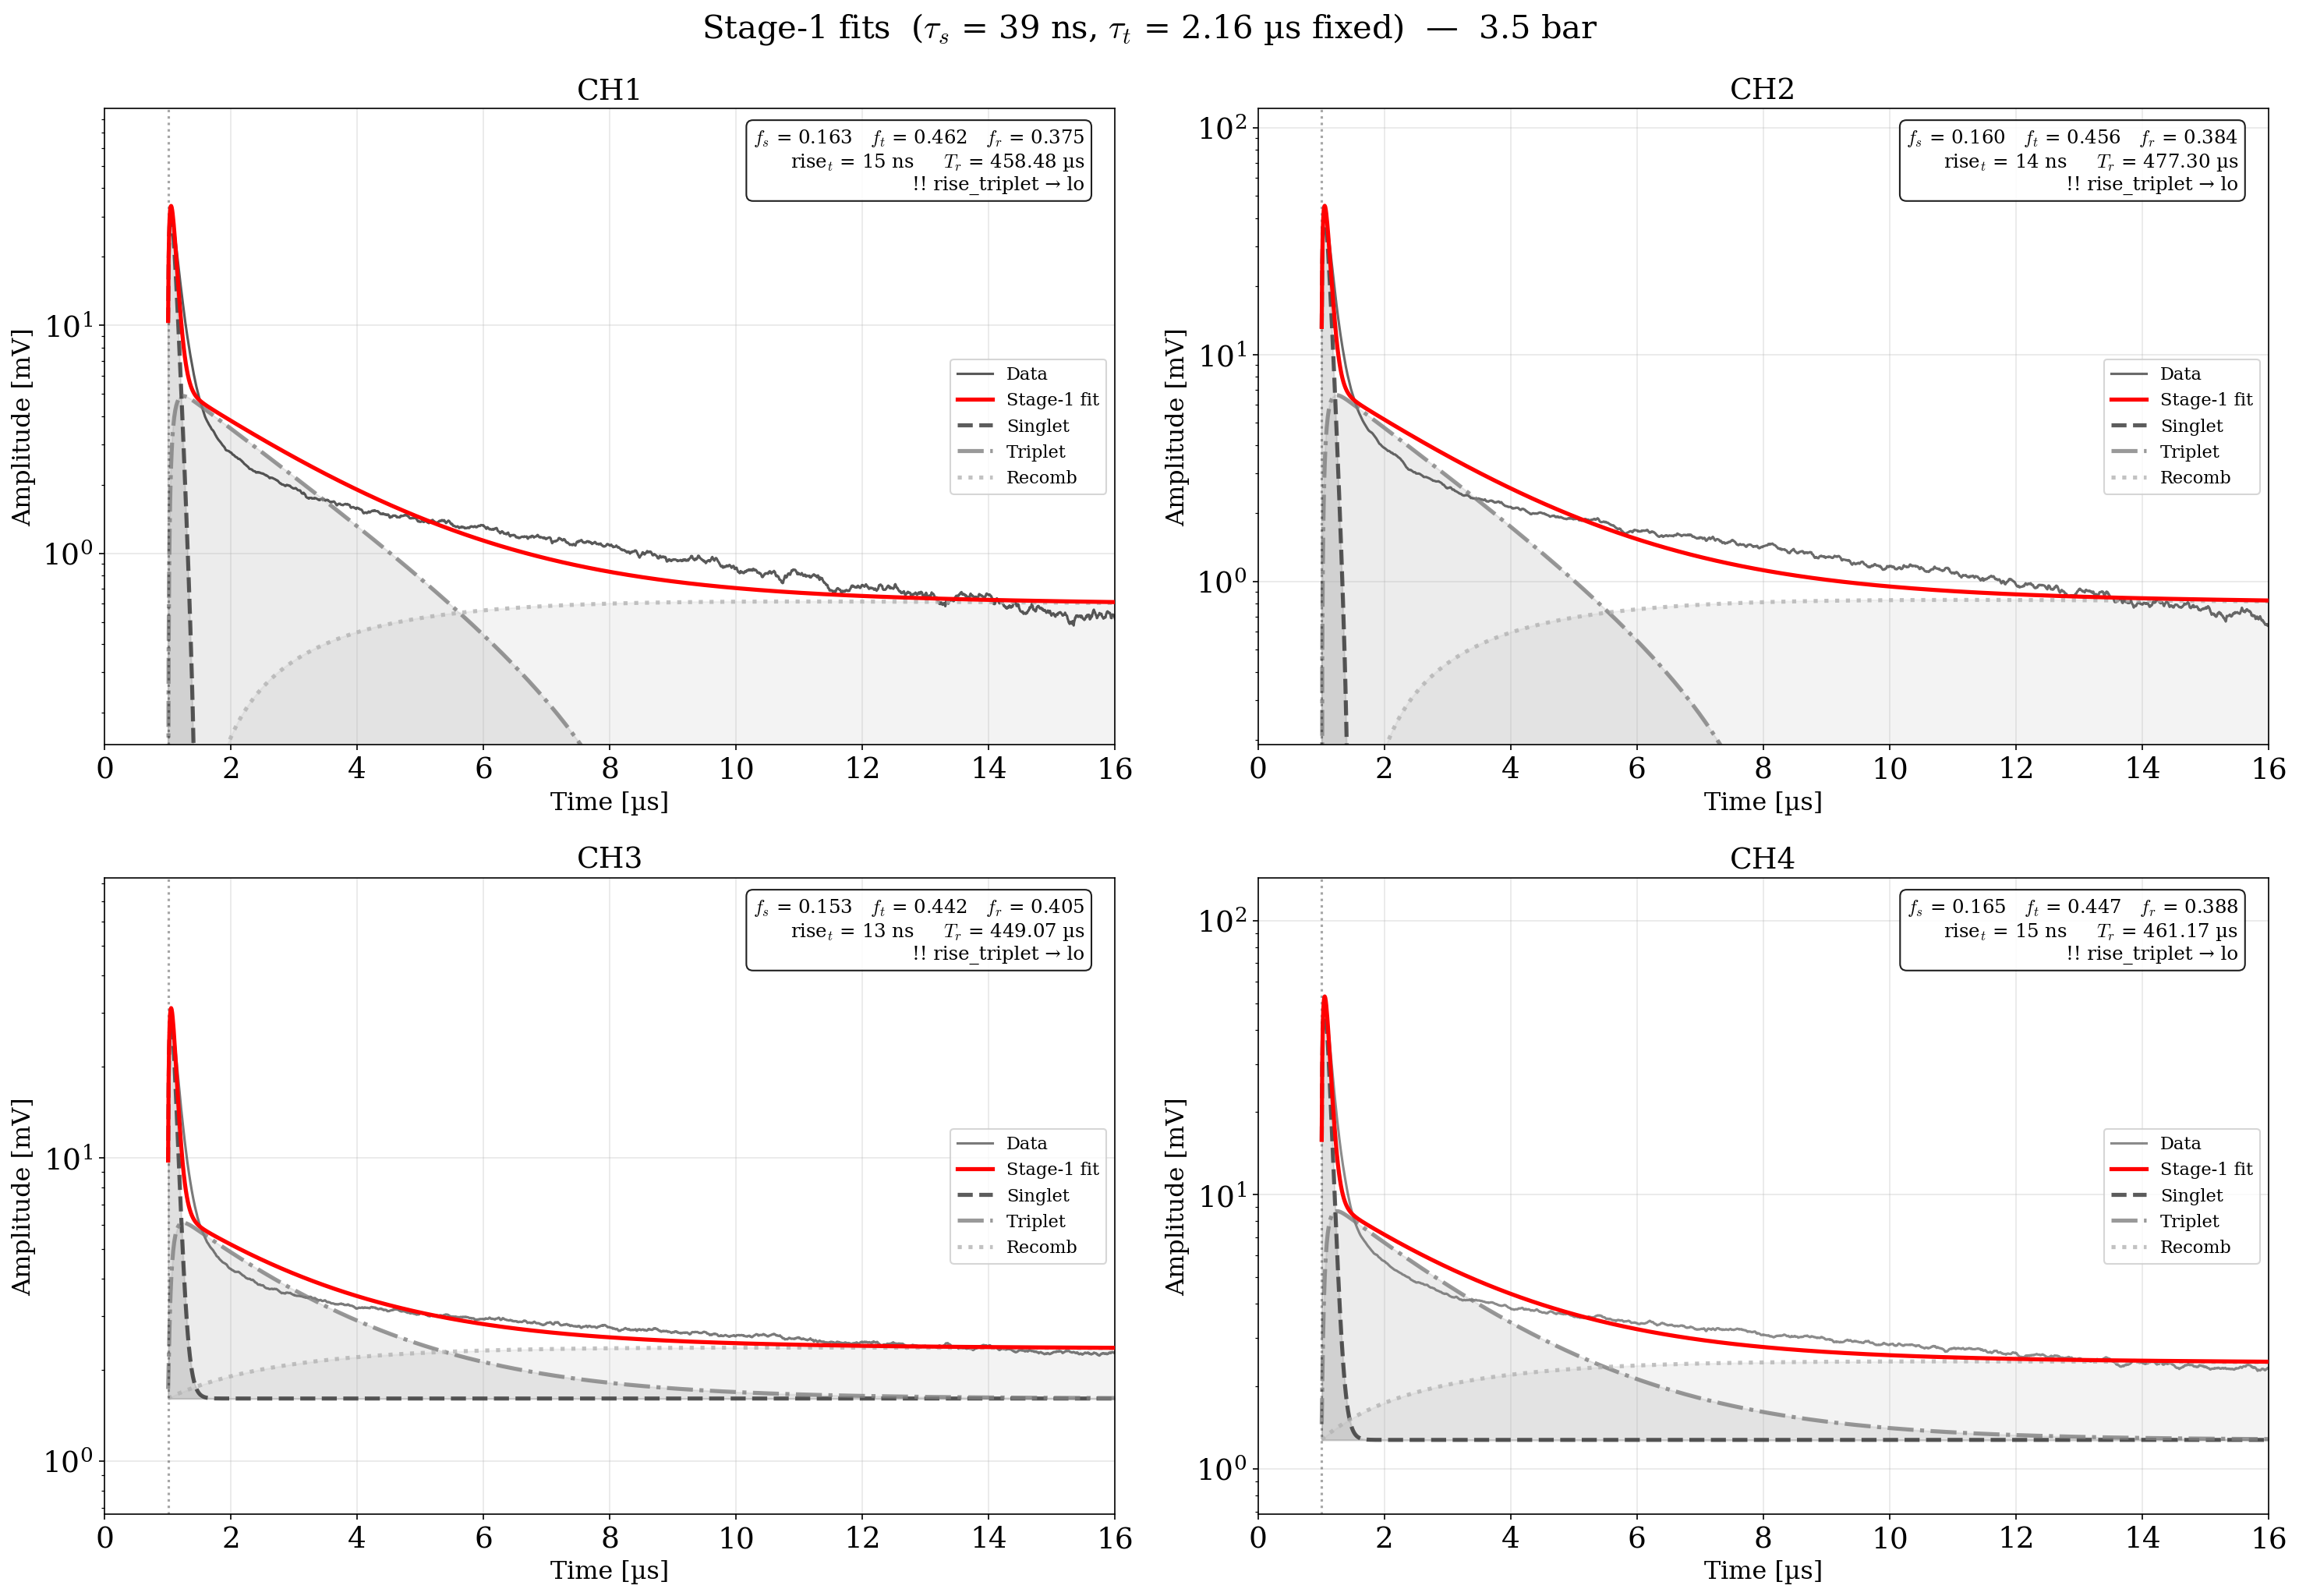


── 2.5 bar (Run183) ─────────────────────
  CH1: fs=0.191  ft=0.609  fr=0.200  rt=15 ns  Tr=642.9 µs  !! rise_triplet → lo
  CH2: fs=0.188  ft=0.598  fr=0.214  rt=14 ns  Tr=657.4 µs  !! rise_triplet → lo
  CH3: fs=0.180  ft=0.580  fr=0.240  rt=14 ns  Tr=650.3 µs  !! rise_triplet → lo
  CH4: fs=0.195  ft=0.596  fr=0.208  rt=15 ns  Tr=650.4 µs  !! rise_triplet → lo


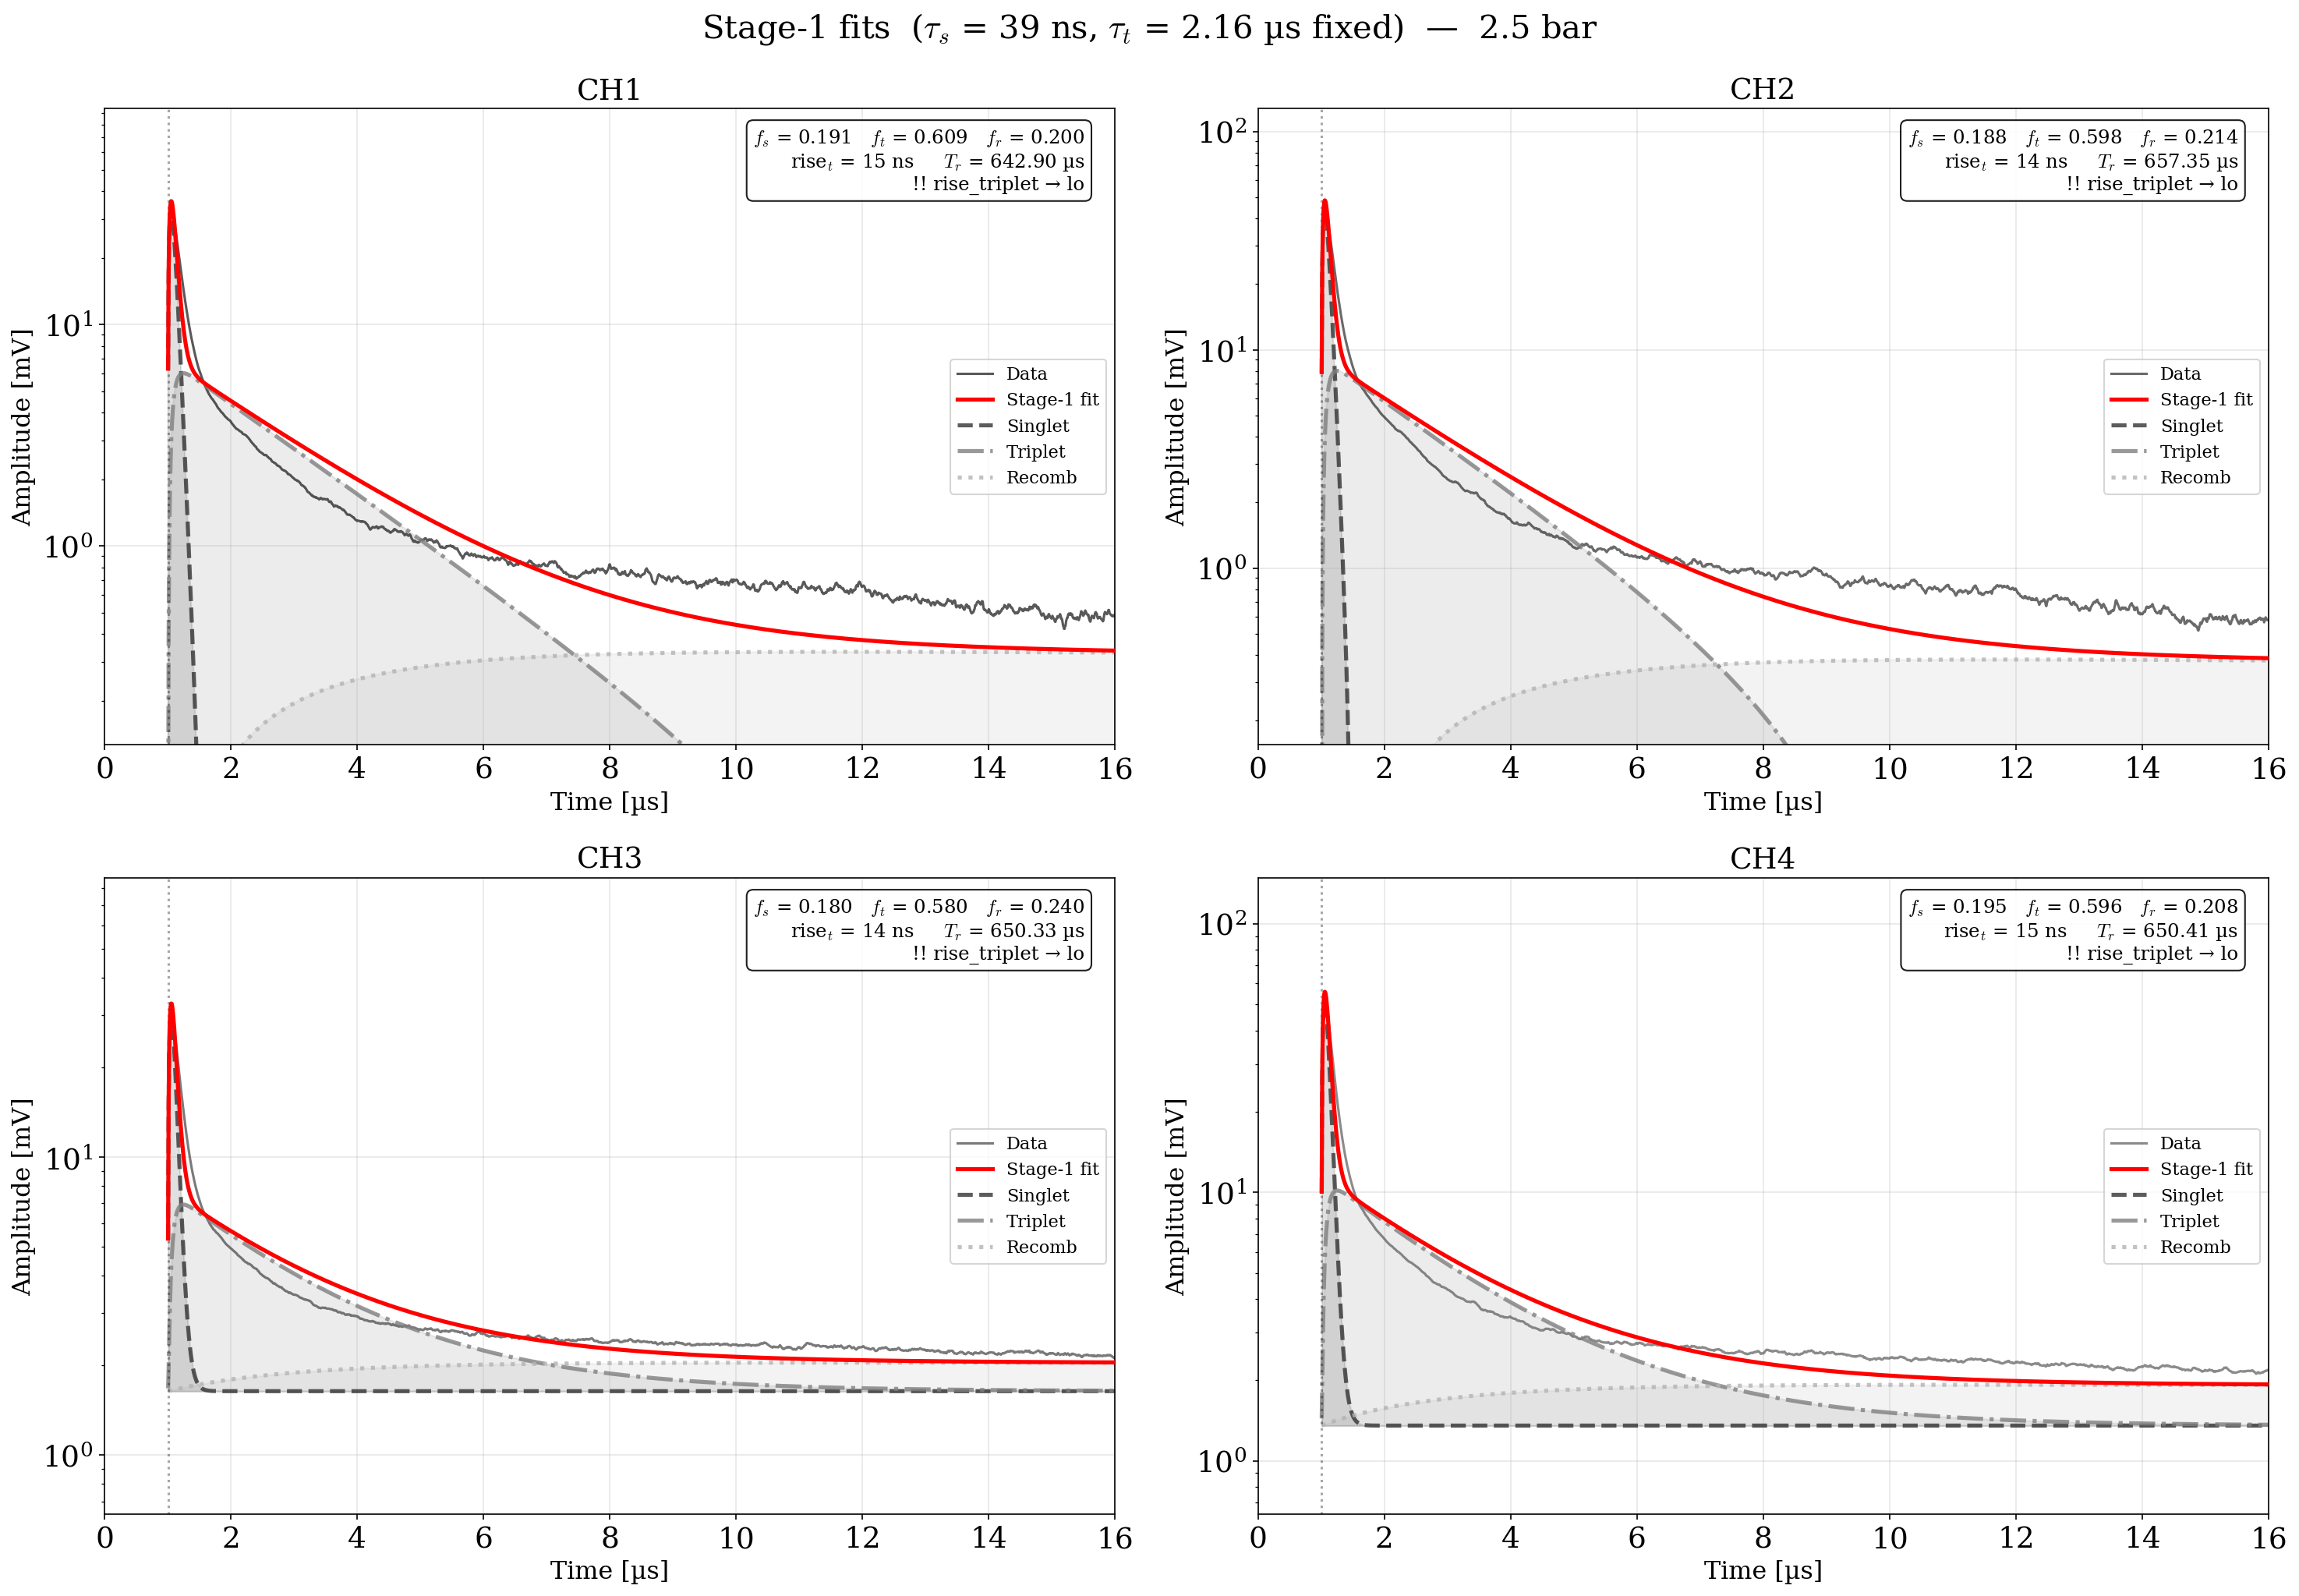


── 1.5 bar (Run185) ─────────────────────
  CH1: fs=0.189  ft=0.759  fr=0.052  rt=12 ns  Tr=869.6 µs  !! rise_triplet → lo  !! A_rec → lo
  CH2: fs=0.189  ft=0.761  fr=0.050  rt=12 ns  Tr=996.7 µs  !! rise_triplet → lo  !! A_rec → lo
  CH3: fs=0.184  ft=0.756  fr=0.059  rt=11 ns  Tr=991.8 µs  !! rise_triplet → lo  !! A_rec → lo
  CH4: fs=0.195  ft=0.756  fr=0.049  rt=13 ns  Tr=908.2 µs  !! rise_triplet → lo  !! A_rec → lo


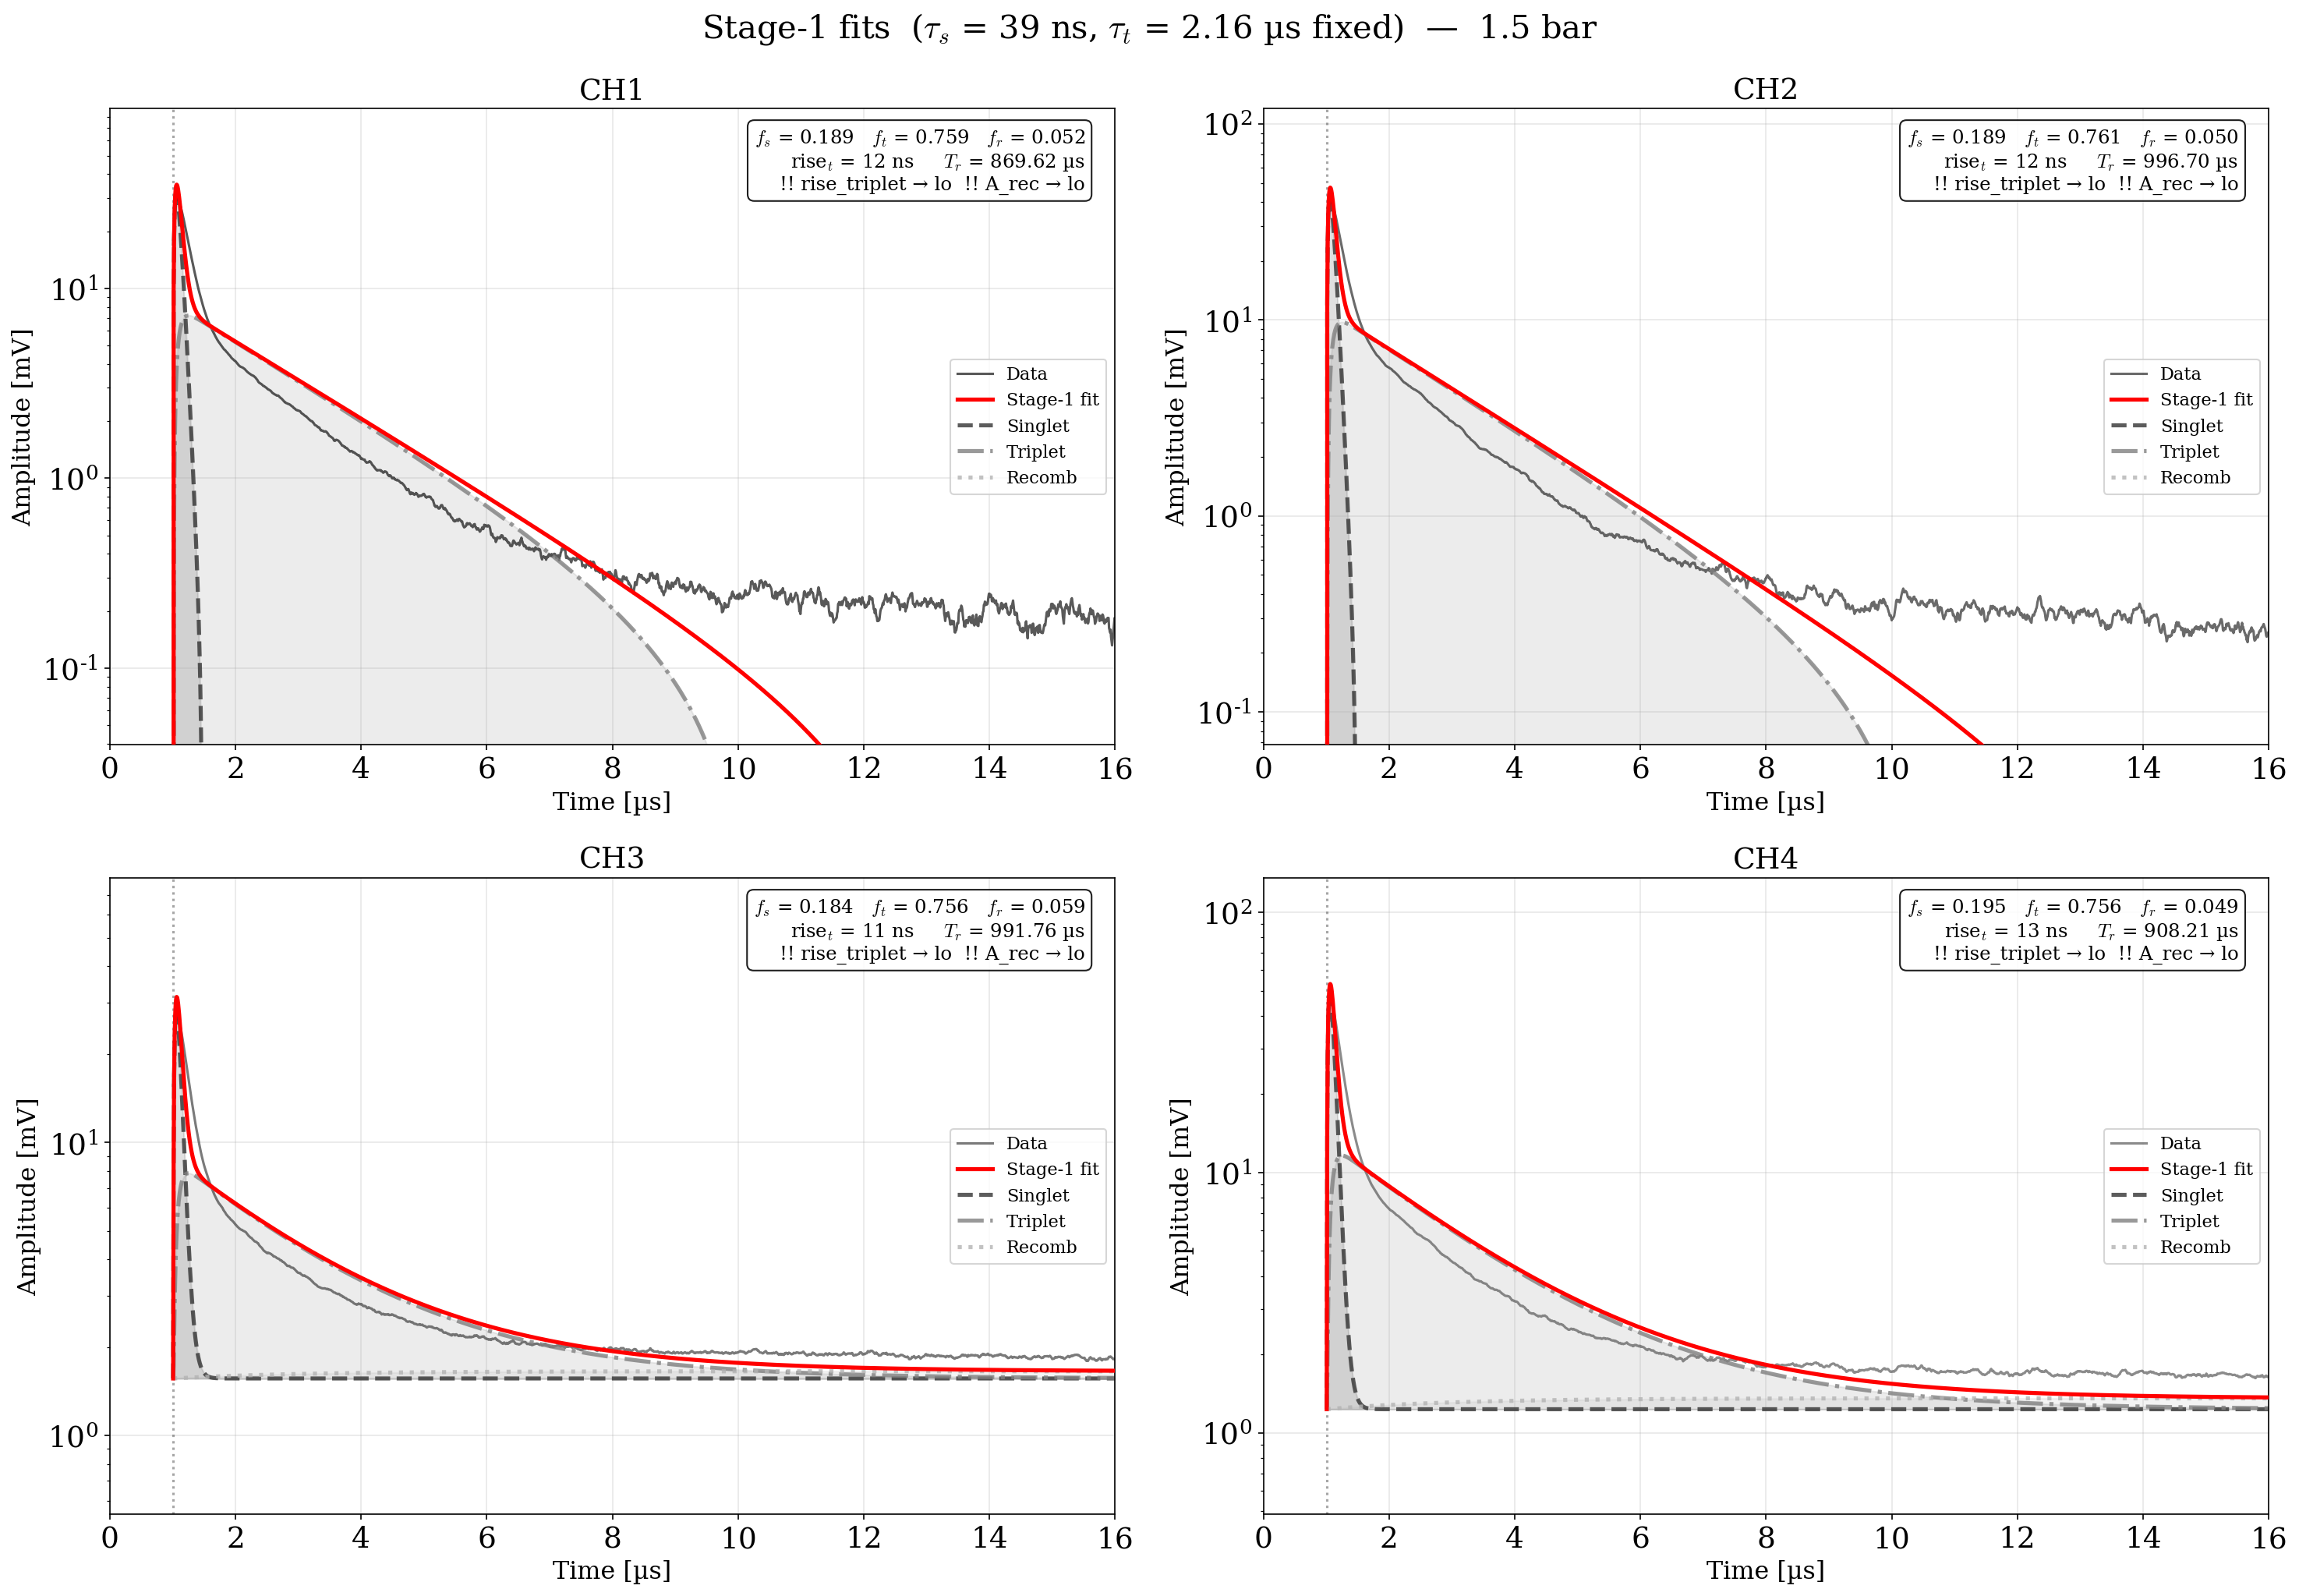


All pressures done!


In [43]:
amp_results = {}   # {ch: {bars: {...}}}

for bars, run_name in sorted(runs.items(), reverse=True):   # 8.5 → 1.5
    npz          = np.load(f'{base}/mean_waveforms/mean_waveforms_{run_name}.npz',
                           allow_pickle=True)
    channels_arr = npz['channels']
    time_arr     = npz['time']

    print(f'\n── {bars} bar ({run_name}) ─────────────────────')

    for ch_idx, ch in enumerate(channels_arr):
        sk = f'CH{ch_idx+1}'
        if sk not in _TR_A:
            continue

        wf           = -npz[f'ch_{ch}'].copy()
        baseline_est = float(np.mean(wf[:pretrigger//3]))
        t0_fixed     = float(time_arr[pretrigger])
        dt_samp      = float(time_arr[1] - time_arr[0])

        fit_mask = time_arr >= t0_fixed
        t_fit    = time_arr[fit_mask]
        wf_fit   = wf[fit_mask]

        Tr_guess = _TR_A[sk] * 1e-6 * bars ** _TR_ALPHA[sk]

        try:
            popt, pcov, A_tot, (lo, hi) = fit_amplitudes_stage1(
                t_fit, wf_fit, t0_fixed, dt_samp, baseline_est, Tr_guess)

            t0_, As, At, rt, Ar, Tr = popt
            perr      = np.sqrt(np.diag(pcov))
            clip_warn = _check_bounds_s1(popt, lo, hi)

            A_sum = As + At + Ar
            f_s   = As / A_sum if A_sum > 0 else np.nan
            f_t   = At / A_sum if A_sum > 0 else np.nan
            f_r   = Ar / A_sum if A_sum > 0 else np.nan

            if sk not in amp_results:
                amp_results[sk] = {}
            amp_results[sk][bars] = dict(
                A_singlet=float(As),   A_triplet=float(At),   A_rec=float(Ar),
                f_singlet=float(f_s),  f_triplet=float(f_t),  f_rec=float(f_r),
                rise_triplet=float(rt),  Tr=float(Tr),
                A_tot=float(A_tot),    t0=float(t0_),
                err_As=float(perr[1]), err_At=float(perr[2]),
                err_Ar=float(perr[4]), err_Tr=float(perr[5]),
                clip_warnings=clip_warn,
                fit_ok=True,
            )

            flag = '  ' + '  '.join(clip_warn) if clip_warn else ''
            print(f'  {sk}: fs={f_s:.3f}  ft={f_t:.3f}  fr={f_r:.3f}  '
                  f'rt={rt*1e9:.0f} ns  Tr={Tr*1e6:.1f} µs{flag}')

        except RuntimeError as e:
            print(f'  {sk}: FAILED — {e}')
            if sk not in amp_results:
                amp_results[sk] = {}
            amp_results[sk][bars] = dict(fit_ok=False, clip_warnings=[])

    # Per-pressure 2×2 figure (all 4 channels), same style as v3
    plot_stage1_at_pressure(bars, run_name, amp_results, base, pretrigger,
                            colors, font_size=18, logscale=True)

print('\nAll pressures done!')

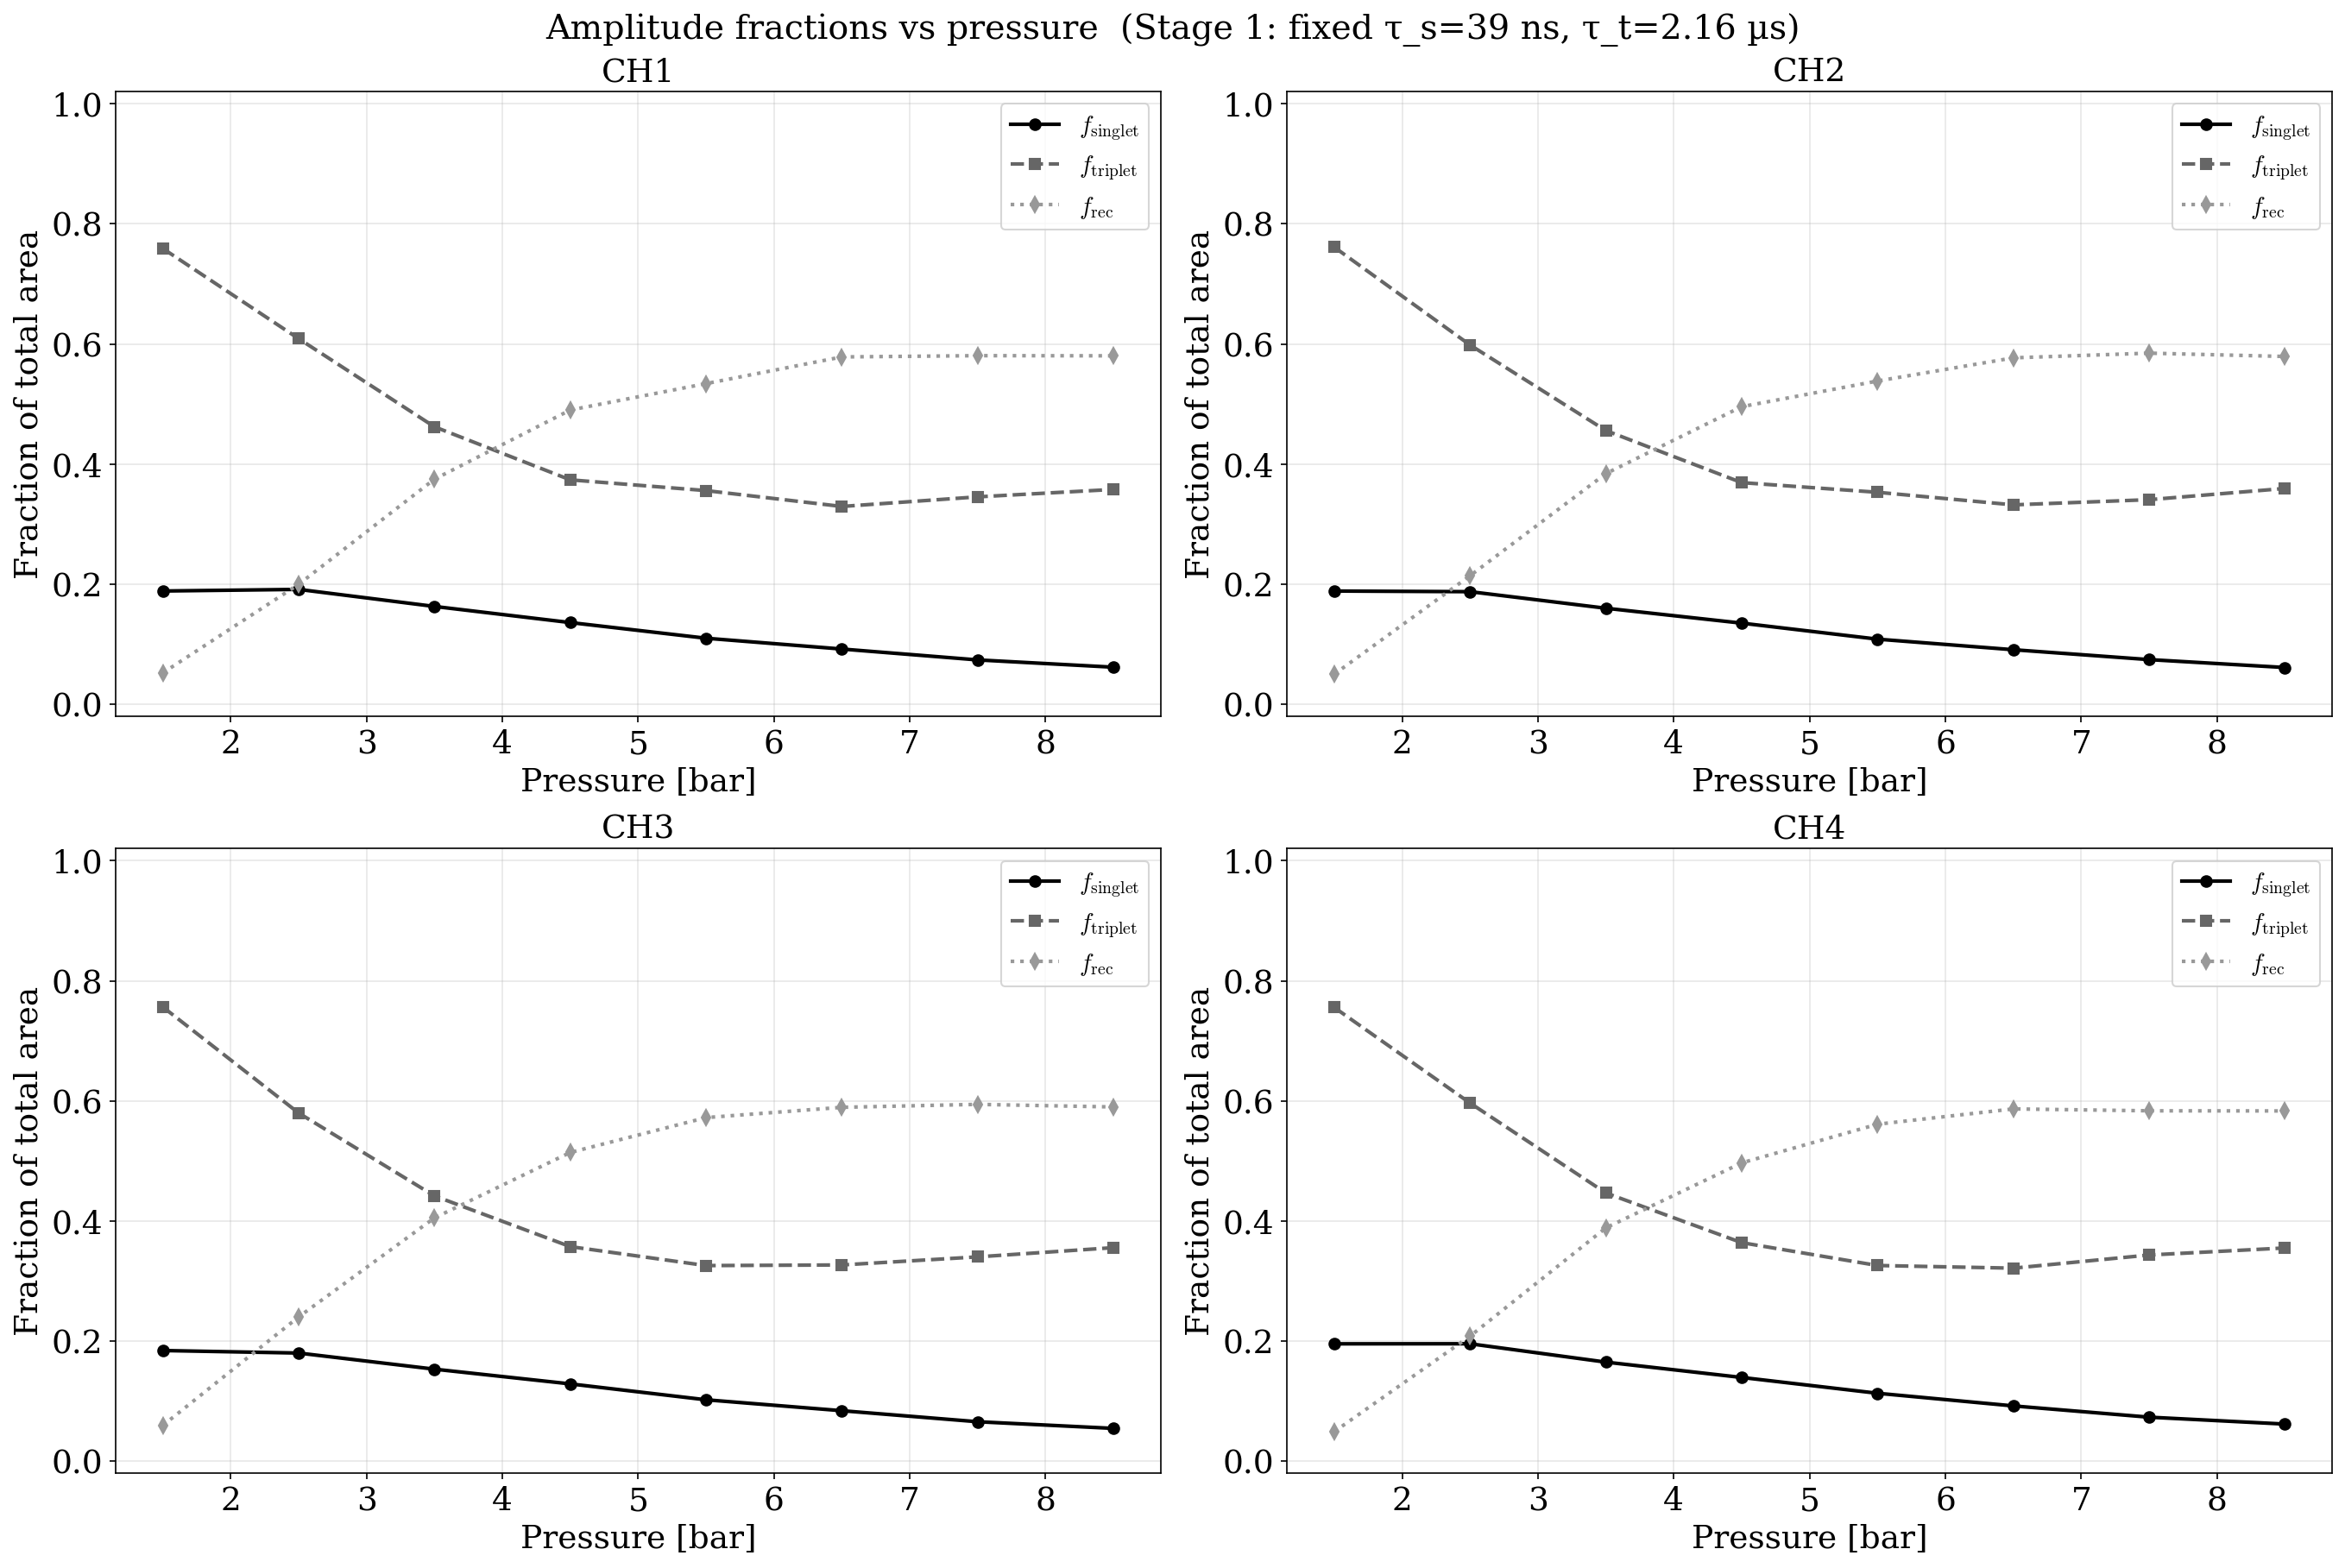

In [44]:
channels_ordered = sorted(amp_results.keys(), key=lambda x: int(x[2:]))

fig, axs = plt.subplots(2, 2, figsize=(18, 12), dpi=150, constrained_layout=True)
fig.suptitle('Amplitude fractions vs pressure  (Stage 1: fixed τ_s=39 ns, τ_t=2.16 µs)',
             fontsize=font_size + 1)

for ii, sk in enumerate(channels_ordered[:4]):
    ax   = axs.flat[ii]
    data = amp_results[sk]
    good = sorted(b for b in data if data[b].get('fit_ok', False))

    fs = [data[b]['f_singlet'] for b in good]
    ft = [data[b]['f_triplet'] for b in good]
    fr = [data[b]['f_rec']     for b in good]

    ax.plot(good, fs, 'o-',  color=colors[0], lw=2, label=r'$f_{\rm singlet}$')
    ax.plot(good, ft, 's--', color=colors[4], lw=2, label=r'$f_{\rm triplet}$')
    ax.plot(good, fr, 'd:',  color=colors[6], lw=2, label=r'$f_{\rm rec}$')

    ax.set_xlabel('Pressure [bar]', fontsize=font_size)
    ax.set_ylabel('Fraction of total area', fontsize=font_size)
    ax.set_title(sk, fontsize=font_size)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=font_size * 0.75)
    ax.grid(True, alpha=0.3)

plt.show()

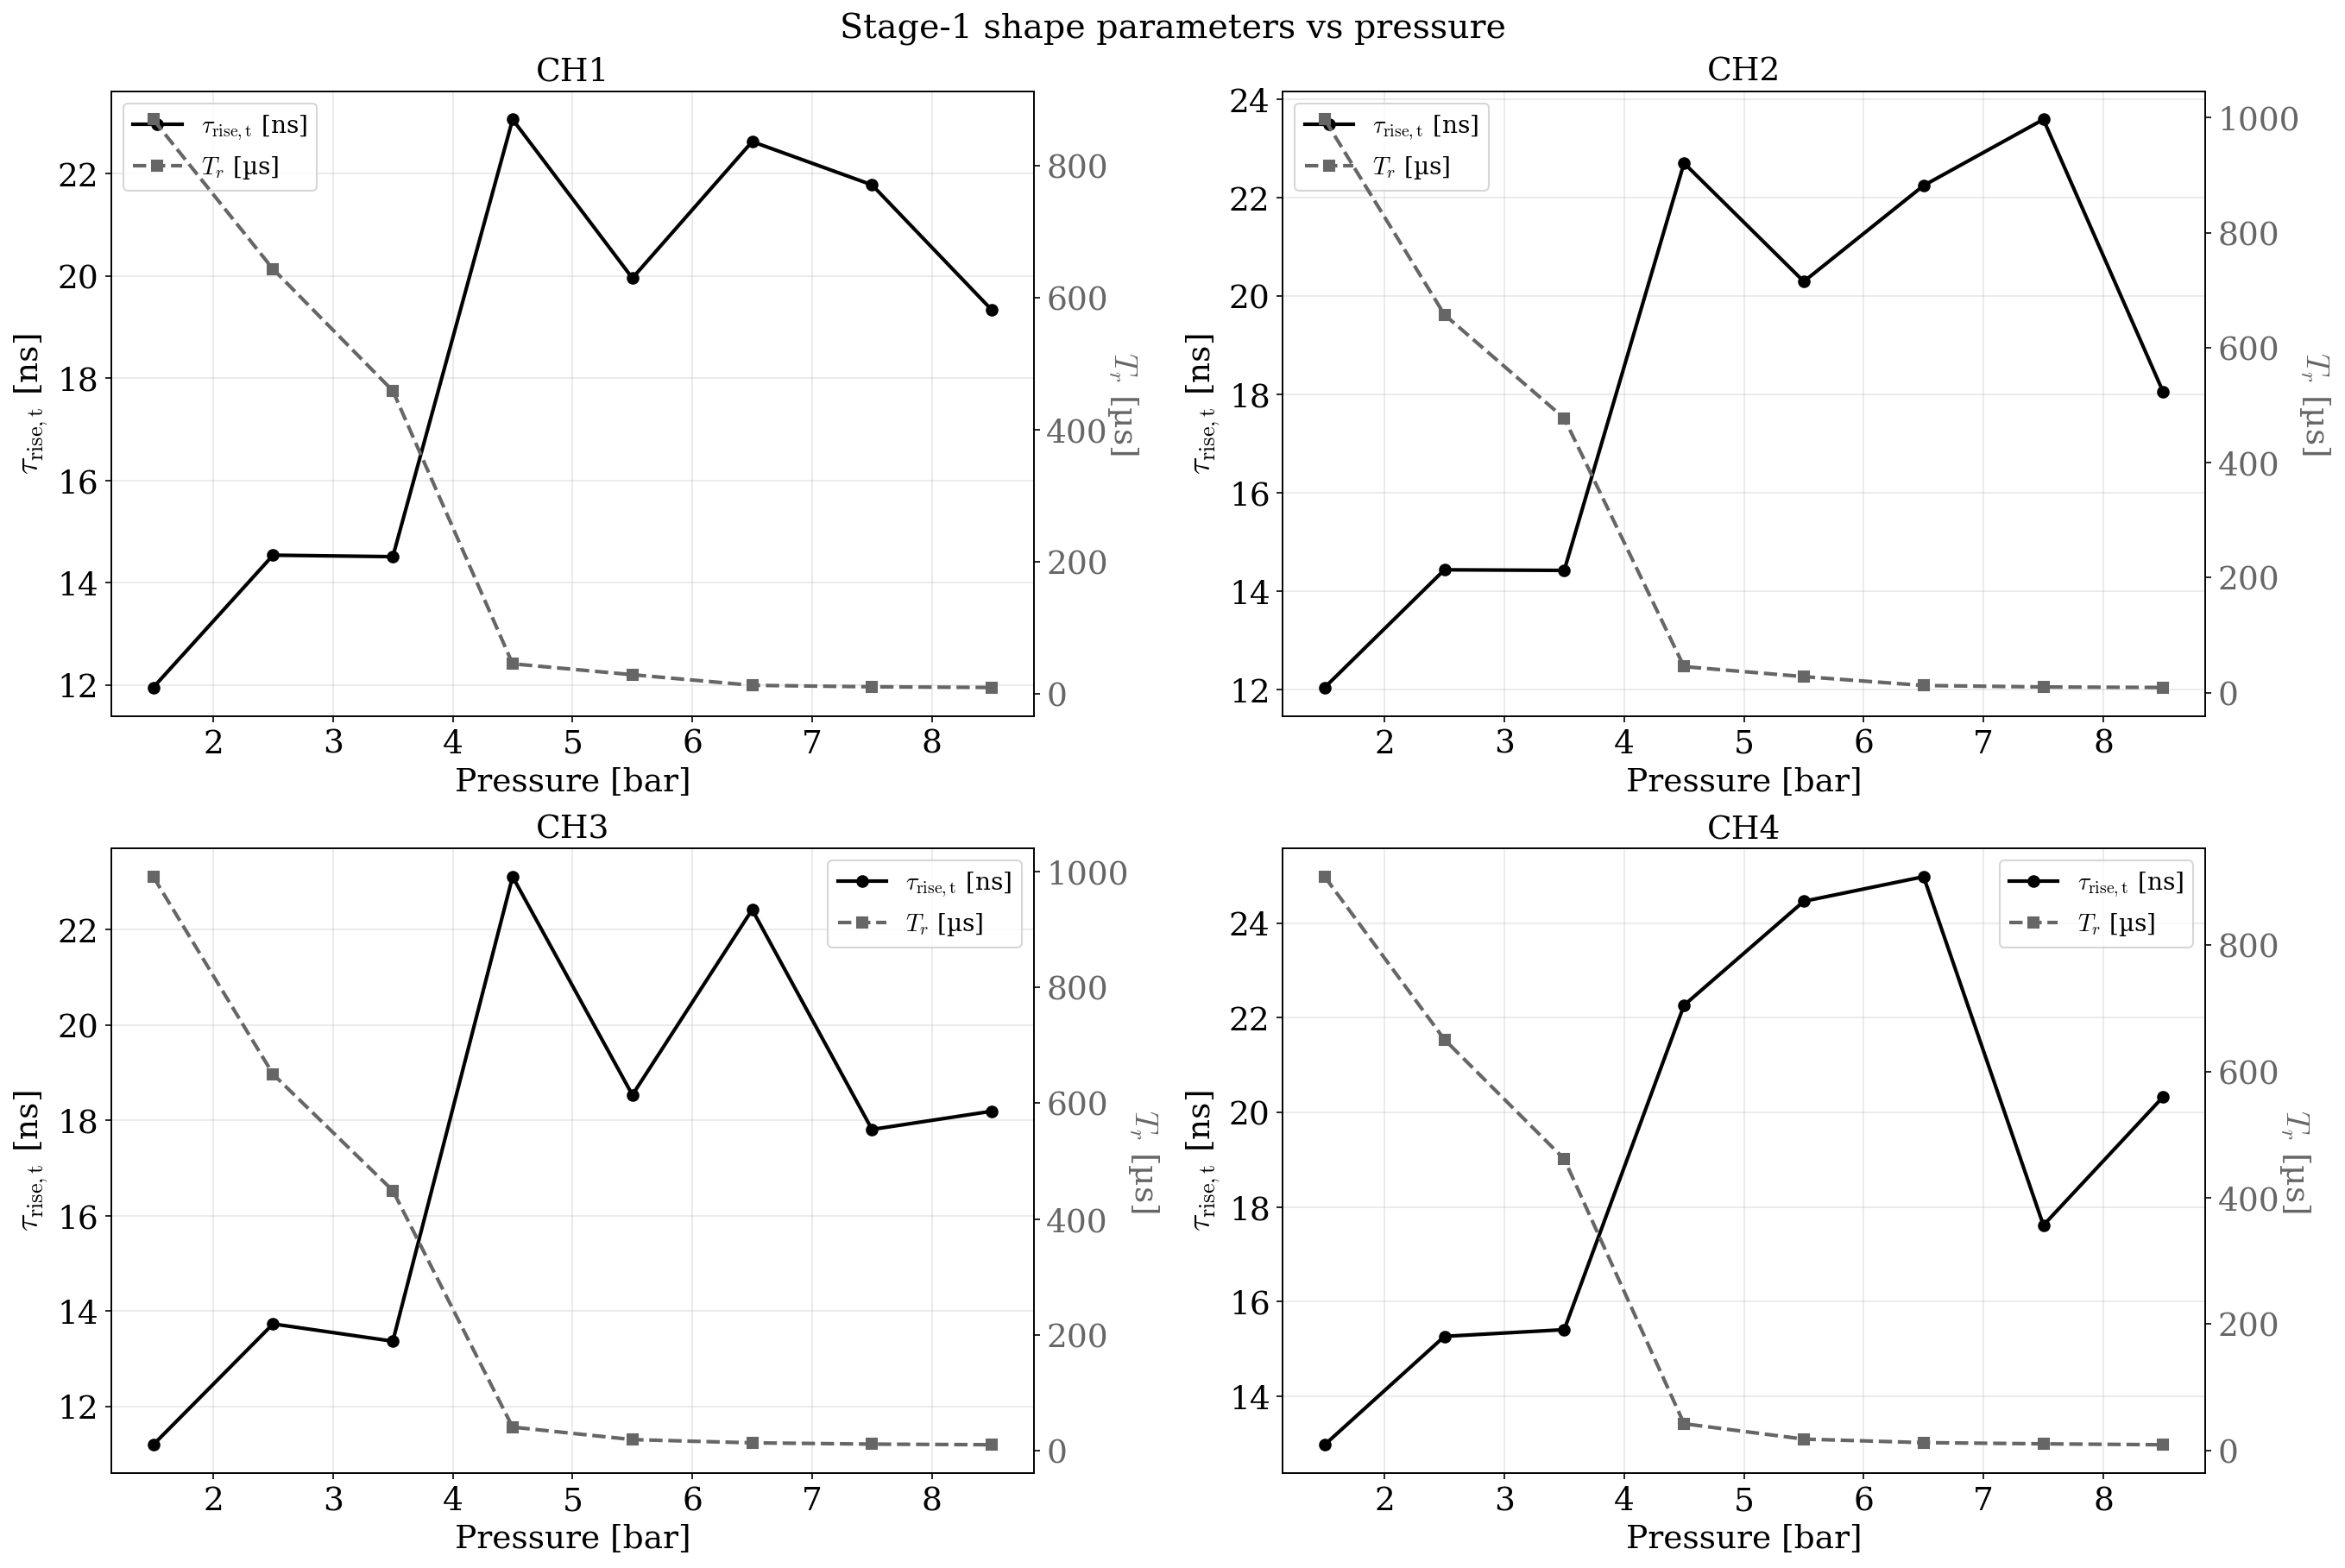

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), dpi=150, constrained_layout=True)
fig.suptitle('Stage-1 shape parameters vs pressure', fontsize=font_size + 1)

for ii, sk in enumerate(channels_ordered[:4]):
    ax   = axs.flat[ii]
    data = amp_results[sk]
    good = sorted(b for b in data if data[b].get('fit_ok', False))

    rt_ns = [data[b]['rise_triplet'] * 1e9  for b in good]
    Tr_us = [data[b]['Tr']           * 1e6  for b in good]

    ax2 = ax.twinx()
    ax.plot(good, rt_ns, 'o-',  color=colors[0], lw=2, label=r'$\tau_{\rm rise,t}$ [ns]')
    ax2.plot(good, Tr_us, 's--', color=colors[4], lw=2, label=r'$T_r$ [µs]')

    ax.set_xlabel('Pressure [bar]', fontsize=font_size)
    ax.set_ylabel(r'$\tau_{\rm rise,t}$ [ns]', fontsize=font_size, color=colors[0])
    ax2.set_ylabel(r'$T_r$ [µs]', fontsize=font_size, rotation=270, labelpad=18,
                   color=colors[4])
    ax2.tick_params(axis='y', labelcolor=colors[4])
    ax.set_title(sk, fontsize=font_size)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=font_size*0.75)
    ax.grid(True, alpha=0.3)

plt.show()

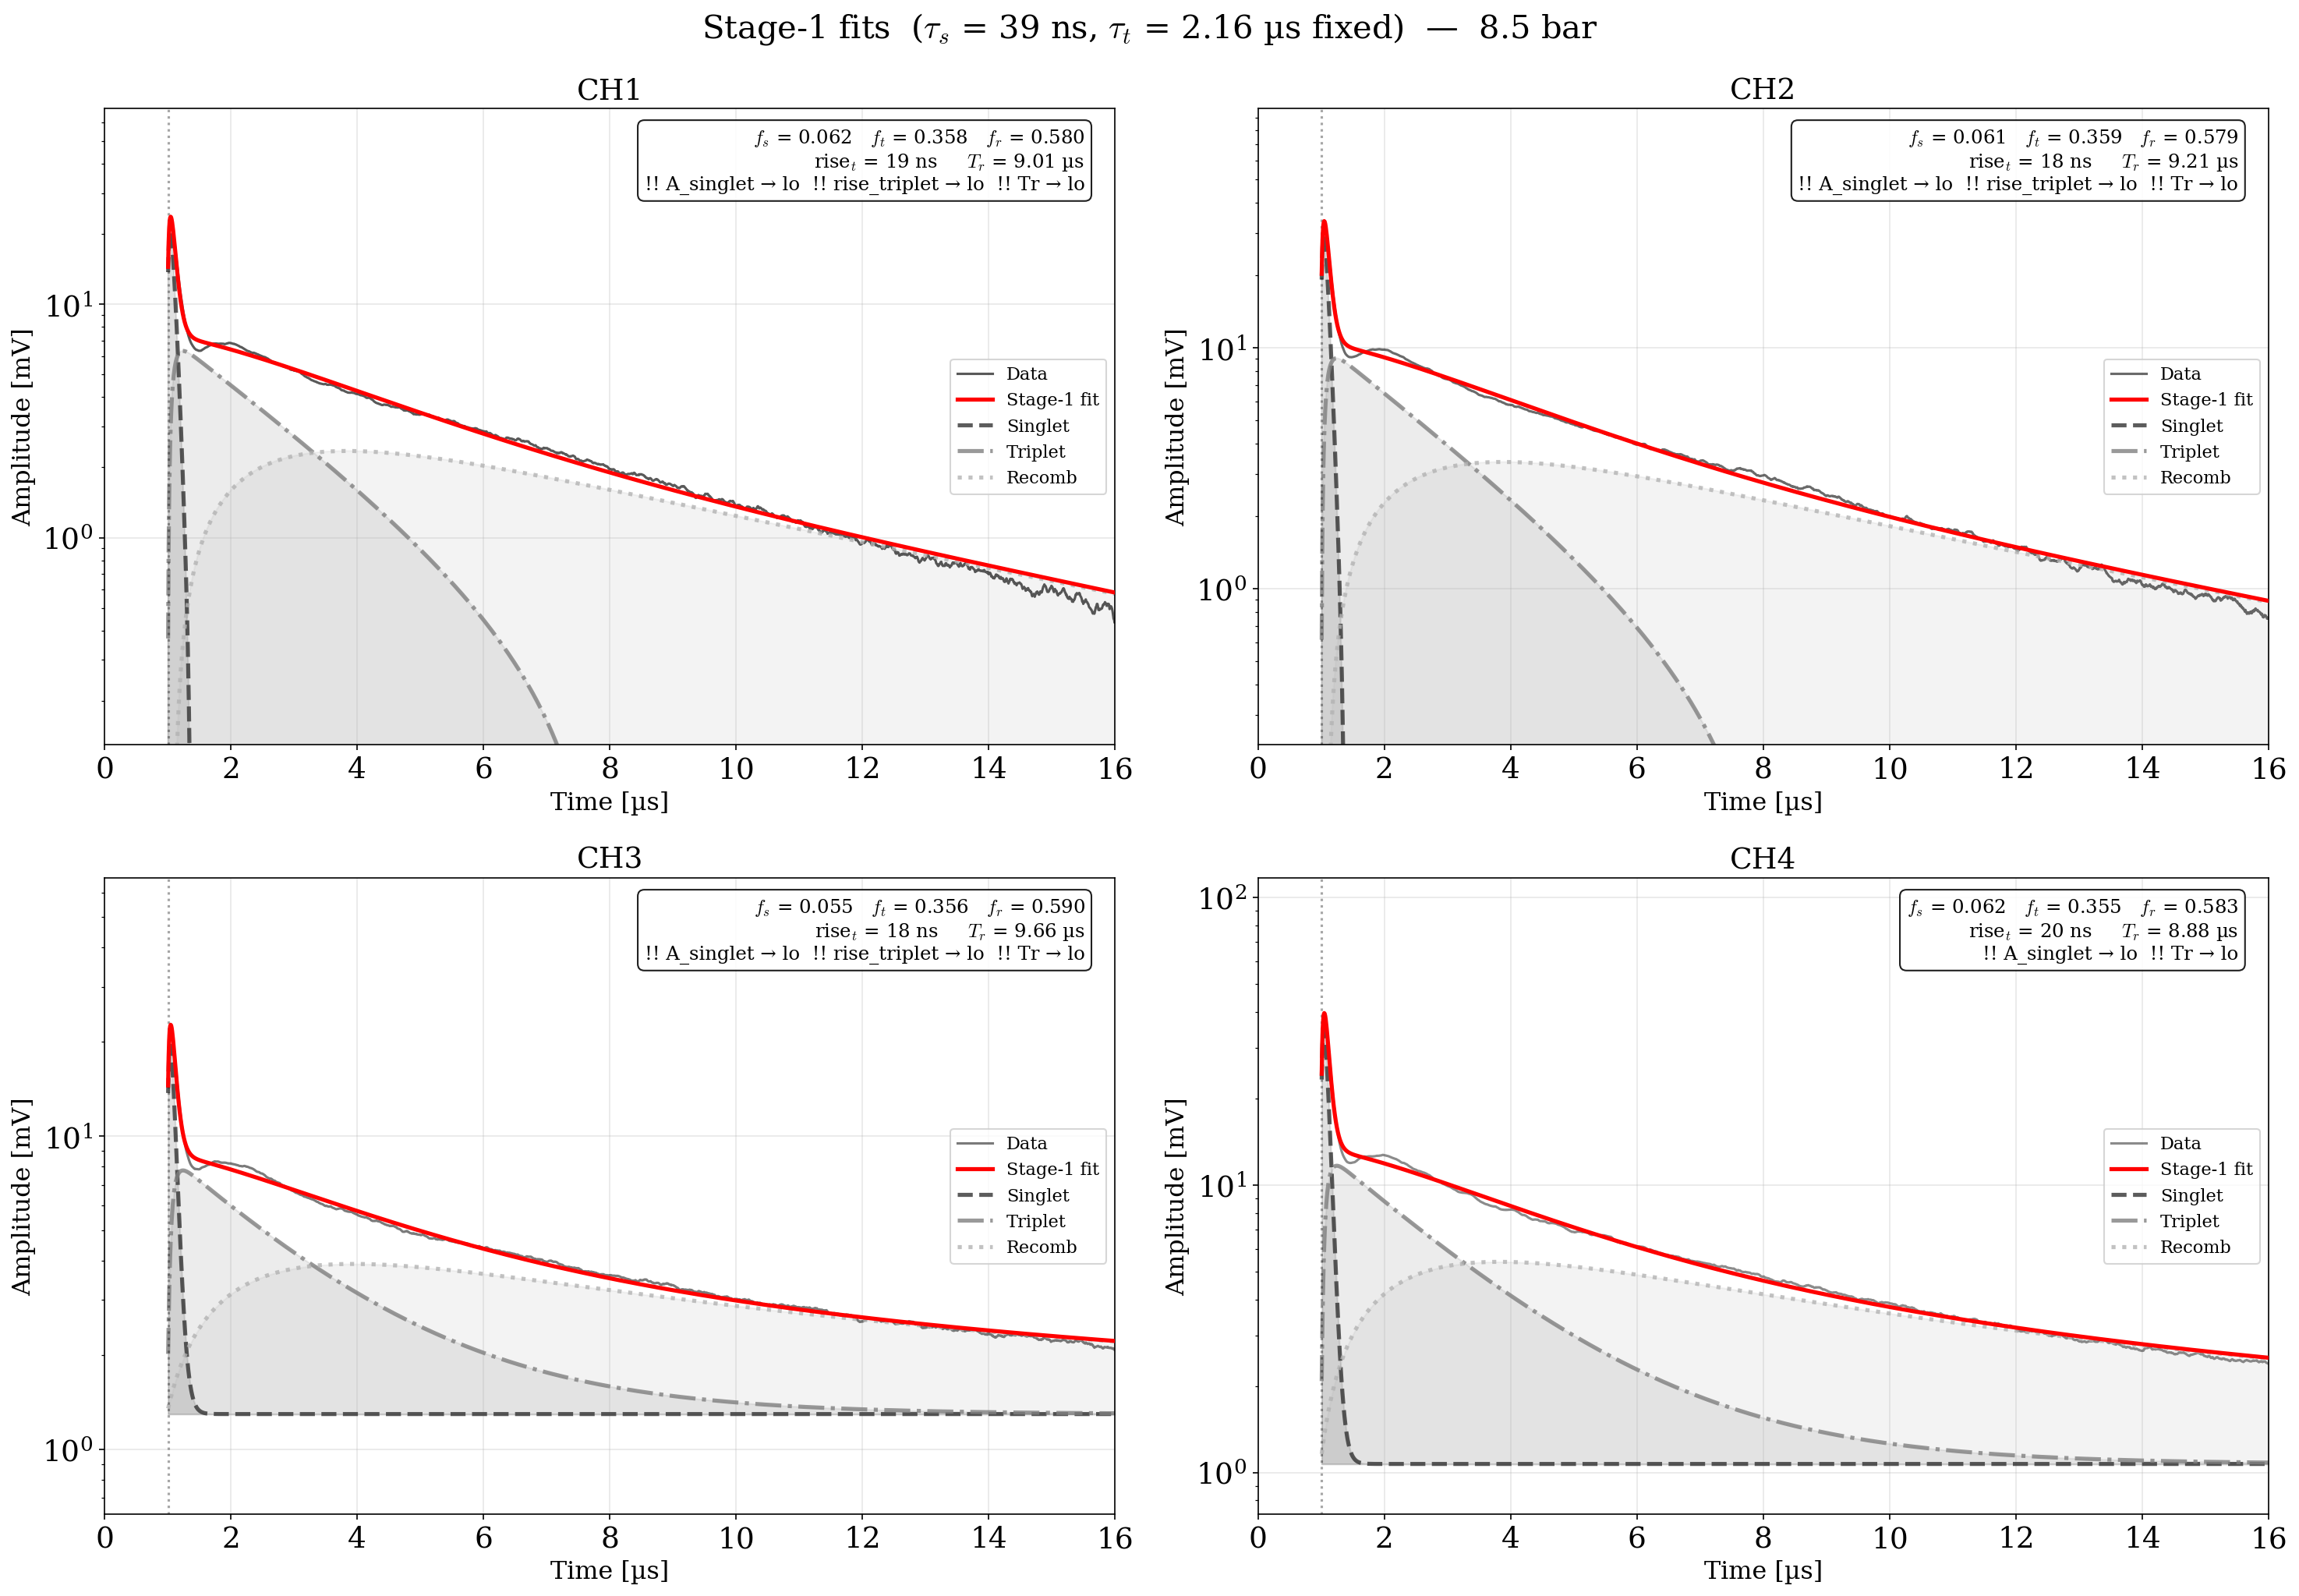

In [46]:
# Re-plot any single pressure for a closer look (edit bars as needed)
plot_stage1_at_pressure(8.5, runs[8.5], amp_results, base, pretrigger,
                        colors, font_size=18, logscale=True)

In [47]:
save_path = f'{output_dir}/amplitude_fractions.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(amp_results, f)
print(f'Saved → {save_path}')

# Summary table
print(f'\n{"":>6}  {"fs":>8}  {"ft":>8}  {"fr":>8}  {"rt[ns]":>8}  {"Tr[µs]":>8}')
for sk in sorted(amp_results):
    print(f'\n{sk}')
    for bars in sorted(amp_results[sk]):
        d = amp_results[sk][bars]
        if d.get('fit_ok', False):
            print(f'  {bars:.1f} bar  {d["f_singlet"]:8.3f}  {d["f_triplet"]:8.3f}'
                  f'  {d["f_rec"]:8.3f}  {d["rise_triplet"]*1e9:8.1f}  {d["Tr"]*1e6:8.2f}')

Saved → /home/marian/CIGAR_ANALYSIS/CIGAR/outputs/amplitude_fractions.pkl

              fs        ft        fr    rt[ns]    Tr[µs]

CH1
  1.5 bar     0.189     0.759     0.052      12.0    869.62
  2.5 bar     0.191     0.609     0.200      14.5    642.90
  3.5 bar     0.163     0.462     0.375      14.5    458.48
  4.5 bar     0.136     0.374     0.490      23.1     44.91
  5.5 bar     0.110     0.356     0.534      20.0     28.37
  6.5 bar     0.092     0.329     0.579      22.6     12.33
  7.5 bar     0.074     0.345     0.581      21.8     10.07
  8.5 bar     0.062     0.358     0.580      19.3      9.01

CH2
  1.5 bar     0.189     0.761     0.050      12.0    996.70
  2.5 bar     0.188     0.598     0.214      14.4    657.35
  3.5 bar     0.160     0.456     0.384      14.4    477.30
  4.5 bar     0.135     0.369     0.496      22.7     45.51
  5.5 bar     0.108     0.353     0.538      20.3     28.09
  6.5 bar     0.091     0.332     0.577      22.2     12.73
  7.5 bar     0.07